# Iteración 2 — HMM + Señal Condicionada + Breakout

**TFM: *Machine Learning aplicado a la Gestión de Inversiones***  
**Línea 1: Identificación de Regímenes y Destilación de Modelos — S&P 500**

---

## Cambios respecto a la versión anterior (reunión con el profesor)

| Parámetro | Antes | Ahora | Motivo |
|---|---|---|---|
| `HMM_N_STATES` | 3 (bull/lateral/bear) | **2 (bull/bear)** | K=3 clasificaba >83% del OOS como no-bull |
| `GAMMA_BULL_THRESHOLD` | 0.50 | **0.30** | Ampliar cobertura temporal del filtro |
| `BREAKOUT_VOL_MULT` | 1.0 | **0.0** | El breakout eliminaba demasiadas señales |

## Objetivo y enfoque

Esta iteración añade detección de régimen de mercado mediante HMM y filtra las señales de la Iteración 1 por la probabilidad de estado alcista γ_t(bull). El énfasis está en la **validación estadística del HMM** (test Mann-Whitney, coeficiente de solapamiento) y en la **explicabilidad del proceso completo**.

## Hipótesis

**H5.** El HMM K=2 identifica dos estados con retornos estadísticamente distintos (bull: μ>0, bear: μ<0), verificado con test Mann-Whitney p<0.05.  
**H6.** La señal condicionada γ_bull>0.30 mejora el Sharpe OOS para al menos un modelo.  
**H7.** El breakout (precio > MA20) reduce el MaxDD sin sacrificar Sharpe.  
**H8.** Las señales iter2 se concentran en periodos con γ_bull alto, evidenciando que el filtro HMM es informativo y no aleatorio.

---
## Nota preliminar para la evaluación académica

El presente notebook constituye la **Iteración 2** del pipeline de aprendizaje automático del TFM, y es la versión definitiva y cerrada que se entrega como parte de la memoria escrita. Construye directamente sobre los artefactos producidos por la Iteración 1, cuya ejecución previa es un prerrequisito.

### Propósito metodológico de esta iteración

La Iteración 2 añade una **capa de contexto de mercado** al pipeline de clasificación mediante la incorporación de un Modelo de Markov Oculto (HMM) gaussiano. El objetivo no es sustituir los clasificadores supervisados de la Iteración 1, sino **filtrar y condicionar** sus señales mediante una estimación probabilística del régimen de mercado actual.

El argumento teórico es el siguiente: los patrones técnicos que predice el clasificador supervisado (EBM, LightGBM, Student) tienen distinta relevancia según el estado del mercado. En un mercado bajista o de alta incertidumbre (régimen *bear*), los patrones alcistas aprendidos por el modelo pueden generar señales falsas con mayor frecuencia. El filtro HMM actúa como un meta-selector: opera las señales del clasificador solo cuando la probabilidad de régimen alcista supera un umbral calibrado.

### Evolución respecto a versiones anteriores

Los cambios realizados en esta iteración respecto a versiones previas siguieron las recomendaciones del director del trabajo y se resumen en la tabla del encabezado del notebook. Su impacto metodológico puede describirse como sigue:

**Reducción de K=3 a K=2 estados HMM**: la versión anterior con K=3 (bull/lateral/bear) clasificaba más del 83% del período OOS 2020-2024 como no-bull (lateral o bear). Esto hacía que el filtro HMM eliminara casi todas las señales del clasificador en el OOS, produciendo una estrategia con muy baja actividad pero también con poco capital en riesgo. El estado 'lateral' absorbía períodos que deberían clasificarse como bull (2020-2021, 2023-2024). Con K=2, la partición es más nítida y la cobertura temporal es representativa del carácter alcista de largo plazo del S&P 500.

**Reducción del umbral GAMMA de 0.50 a 0.30**: con K=2 y umbral 0.50, seguían perdiéndose demasiadas señales en períodos de transición entre regímenes (donde el modelo HMM asigna probabilidades cercanas a 0.50). El umbral 0.30 amplía la cobertura preservando el carácter filtrador del HMM para días de régimen claramente bajista.

**Eliminación del componente de volatilidad en el breakout (`BREAKOUT_VOL_MULT = 0.0`)**: el componente de volatilidad en la señal de breakout original (`precio > MA20 + k·vol`) eliminaba señales en períodos de alta volatilidad que coincidían con mercados alcistas (por ejemplo, 2020-H2). Al eliminarlo y usar solo `precio > MA20`, la señal de breakout es más limpia y menos correlacionada con el filtro HMM (que ya incorpora volatilidad en su espacio de features).

---
# 0. Configuración global

In [ ]:
import random, os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timezone
from scipy import stats

warnings.filterwarnings('ignore')
import subprocess

! pip install git+https://github.com/christophM/rulefit.git
for package, import_name in [('optuna', 'optuna'), ('imodels', 'imodels')]:
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        subprocess.run(['pip', 'install', package, '-q'], check=True)
def utcnow(): return datetime.now(timezone.utc)

from google.colab import drive

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Splits temporales (idénticos a Iter 1) ───────────────────────────────
TRAIN_END = '2019-12-31'
OOS_START = '2020-01-01'
OOS_END   = '2024-12-31'
WF_FIRST_TRAIN_END = '2013-12-31'
WF_VAL_WINDOW      = 1
TARGET_COL         = 'target_tb'
TRADING_DAYS       = 252
SPREAD             = 0.0005

# ── HMM ──────────────────────────────────────────────────────────────────
HMM_N_STATES  = 2       # K=2: bull / bear (recomendación profesor: simplificar)
HMM_COV_TYPE  = 'full'  # covarianza completa: captura correlación ret-vol
HMM_N_ITER    = 200     # máx iteraciones Baum-Welch
HMM_N_INIT    = 5       # reinicializaciones para evitar óptimos locales

# ── Señal condicionada ────────────────────────────────────────────────────
# γ_t(bull) > GAMMA_BULL_THRESHOLD → operar
GAMMA_BULL_THRESHOLD = 0.30  # bajado de 0.50 (recomendación profesor)

# ── Breakout ─────────────────────────────────────────────────────────────
BREAKOUT_MA_WINDOW  = 20   # ventana media móvil para señal de ruptura
BREAKOUT_VOL_WINDOW = 20   # ventana volatilidad para confirmar breakout
BREAKOUT_VOL_MULT   = 0.0  # solo MA20, sin componente de volatilidad (recomendación profesor)

# ── Modelos base ─────────────────────────────────────────────────────────
# 'student' es el modelo de destilación del LGBM serializado por Iter 1
# como student_fold{n}.pkl (RuleFit si convergió, DT si no).
# Se analiza junto a EBM y LGBM para comparar los tres niveles de
# interpretabilidad: exacta (EBM), post-hoc (LGBM-SHAP), reglas (student).
MODEL_PREFIXES        = ['ebm', 'lgbm', 'student']
MODEL_DISPLAY_NAMES   = {'ebm': 'EBM', 'lgbm': 'LightGBM', 'student': 'Student (DT/RuleFit)'}

# ── Rutas Drive ──────────────────────────────────────────────────────────
DRIVE_ROOT    = '/content/drive/MyDrive/tfm'
DRIVE_DATA    = os.path.join(DRIVE_ROOT, 'data')
DRIVE_ITER1   = os.path.join(DRIVE_ROOT, 'iter1')
DRIVE_ITER2   = os.path.join(DRIVE_ROOT, 'iter2')

PATH_DATASET  = os.path.join(DRIVE_DATA,  'dataset_sp500_bloque0.parquet')
PATH_FEATURES = os.path.join(DRIVE_DATA,  'feature_list_bloque0.csv')
PATH_OOS_SIG  = os.path.join(DRIVE_ITER1, 'results', 'oos_signals_iter1.csv')
PATH_FIN_MET  = os.path.join(DRIVE_ITER1, 'results', 'backtest_financial_metrics.csv')

DIR_I2_MODELS  = os.path.join(DRIVE_ITER2, 'models')
DIR_I2_RESULTS = os.path.join(DRIVE_ITER2, 'results')

print(f'✅ Config cargada [{utcnow().strftime("%Y-%m-%d %H:%M UTC")}]')
print(f'   HMM: K={HMM_N_STATES}, cov={HMM_COV_TYPE}, n_init={HMM_N_INIT}')
print(f'   Señal condicionada: γ_bull > {GAMMA_BULL_THRESHOLD}')
print(f'   Breakout: MA{BREAKOUT_MA_WINDOW}, vol×{BREAKOUT_VOL_MULT}')
print(f'   Modelos base: {MODEL_PREFIXES}')

  Cloning https://github.com/christophM/rulefit.git to /tmp/pip-req-build-3lt910s1
  Running command git clone --filter=blob:none --quiet https://github.com/christophM/rulefit.git /tmp/pip-req-build-3lt910s1
  Resolved https://github.com/christophM/rulefit.git to commit 472b8574b4eb9e565caf1e05ed580998fe2c9a8e
  Preparing metadata (setup.py) ... done
  Created wheel for RuleFit: filename=RuleFit-0.3-py3-none-any.whl size=8083 sha256=74d60bc63600a7ea4a49d8d1511af1b09477f3e0d0c672dcbe42387ce8c4fa8b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ng40ow9x/wheels/ed/87/dd/1fdc25e41413ca2cedc61dd3c731b55176c8ee07b4da322802
Successfully built RuleFit
✅ Config cargada [2026-05-05 08:45 UTC]
   HMM: K=2, cov=full, n_init=5
   Señal condicionada: γ_bull > 0.3
   Breakout: MA20, vol×0.0
   Modelos base: ['ebm', 'lgbm', 'student']


### Configuración global de la Iteración 2 — justificación de parámetros HMM

La configuración de la Iteración 2 hereda los parámetros temporales de la Iteración 1 (`TRAIN_END`, `OOS_START`, `OOS_END`, `SEED`) para garantizar la comparabilidad directa de los resultados. Los parámetros específicos de esta iteración son:

**`HMM_N_STATES = 2`**: la elección de K=2 estados frente al K=3 de versiones anteriores responde a un criterio de parsimonia *(principio de Occam)*: el modelo más simple que explica los datos es preferible. En el contexto de los mercados financieros, la dicotomía bull/bear tiene larga tradición en la literatura *(Hamilton, 1989; Ang & Timmermann, 2012)* y ofrece una interpretación económica clara.

**`HMM_COV_TYPE = 'full'`**: la covarianza completa permite capturar la correlación entre retorno y volatilidad dentro de cada estado. En finanzas, esta correlación tiene signo negativo en mercados eficientes (alta volatilidad asociada a retornos negativos), lo que es precisamente la información que distingue el estado bear del bull. Una covarianza diagonal ignoraría esta relación.

**`HMM_N_INIT = 5`**: el algoritmo de Baum-Welch (EM para HMM) es sensible a las condiciones iniciales. Cinco reinicializaciones con semillas distintas y selección del mejor log-verosímil garantizan una convergencia robusta *(Rabiner, 1989)*.

**`GAMMA_BULL_THRESHOLD = 0.30`**: operar cuando la probabilidad *suavizada* de estado bull supera el 30% es deliberadamente permisivo: el HMM actúa como filtro de los días claramente bajistas (γ_bull < 0.30), no como selector de los días óptimamente alcistas (lo que requeriría un umbral mucho más alto). Esta elección maximiza la cobertura temporal manteniendo la función de filtro de régimen adverso.

---
## 0.1 Montar Google Drive y verificar artefactos

In [ ]:
drive.mount('/content/drive', force_remount=False)
os.makedirs(DIR_I2_MODELS,  exist_ok=True)
os.makedirs(DIR_I2_RESULTS, exist_ok=True)

required = {
    'Dataset Bloque 0'         : PATH_DATASET,
    'Feature list'             : PATH_FEATURES,
    'Señales OOS Iter 1'       : PATH_OOS_SIG,
    'Métricas financieras Iter1': PATH_FIN_MET,
}
missing = {k: v for k, v in required.items() if not os.path.exists(v)}
if missing:
    raise FileNotFoundError(
        'Artefactos no encontrados:\n' +
        '\n'.join(f'  ✗ {k}: {v}' for k, v in missing.items()) +
        '\n→ Ejecuta Bloque_0 e Iteracion_1 primero.'
    )

# Verificar modelos Iter 1 por fold
# El student puede estar en student_fold{n}.pkl, rulefit_fold{n}.pkl o dt_fold{n}.pkl
missing_models = []
STUDENT_FILE_MAP = {}  # fold -> nombre real del archivo
for fn in range(1, 7):
    for candidate in [f'student_fold{fn}.pkl', f'rulefit_fold{fn}.pkl', f'dt_fold{fn}.pkl']:
        p = os.path.join(DRIVE_ITER1, 'models', candidate)
        if os.path.exists(p):
            STUDENT_FILE_MAP[fn] = candidate
            break
    if fn not in STUDENT_FILE_MAP:
        missing_models.append(f'student_fold{fn} (ningún candidato encontrado)')
for prefix in ['ebm', 'lgbm']:
    for fn in range(1, 7):
        p = os.path.join(DRIVE_ITER1, 'models', f'{prefix}_fold{fn}.pkl')
        if not os.path.exists(p):
            missing_models.append(p)
if missing_models:
    print(f'  ⚠️  Modelos no encontrados: {missing_models}')
    print('  Algunas secciones de validación por fold no estarán disponibles.')

print('✅ Artefactos verificados:')
for name, path in required.items():
    print(f'   {name:<35} {os.path.getsize(path)/1024:.0f} KB')

Mounted at /content/drive
✅ Artefactos verificados:
   Dataset Bloque 0                    1671 KB
   Feature list                        0 KB
   Señales OOS Iter 1                  83 KB
   Métricas financieras Iter1          0 KB


### Verificación de artefactos — encadenamiento con la Iteración 1

La verificación explícita de los artefactos de la Iteración 1 antes de ejecutar ningún modelo es una decisión de diseño que garantiza la integridad del pipeline encadenado. En particular, el notebook verifica:

- Los archivos de señales OOS de la Iteración 1 (`oos_signals_iter1.csv`): estos son la entrada principal del backtest comparativo. Si no existieran, la Iteración 2 no podría calcular la mejora incremental del filtro HMM respecto a la línea base.

- Los modelos del Bloque de Clasificación (`ebm_fold{n}.pkl`, `lgbm_fold{n}.pkl`, `student_fold{n}.pkl`): estos modelos son necesarios para la sección 6 (validación de la señal condicionada en walk-forward), donde se regeneran las predicciones sobre los folds de validación con y sin el filtro HMM.

La lógica `STUDENT_FILE_MAP` es un elemento de robustez importante: permite que el notebook funcione independientemente de si el student definitivo de la Iteración 1 es un RuleFit, un DT, o se guardó con el nombre genérico `student_fold{n}.pkl`.

---
# 1. Carga de datos y construcción de features HMM

Las features del HMM capturan las dos dimensiones fundamentales del estado del mercado: **dirección** (retorno log) y **riesgo** (volatilidad realizada). Si el VIX está disponible en el dataset, se añade como tercera dimensión (volatilidad implícita prospectiva).

- `ret_log`: $r_t = \ln(P_t/P_{t-1})$ — retorno logarítmico diario.
- `vol_ewm20`: $\sigma_t = \text{EWM}_{20}(r_t^2)^{1/2}$ — volatilidad realizada.
- `vix_norm`: $(\text{VIX}_t - \bar{\text{VIX}}) / \sigma_{\text{VIX}}$ — si disponible.

In [ ]:
def load_data():
    df = pd.read_parquet(PATH_DATASET)
    feature_cols = pd.read_csv(PATH_FEATURES)['feature'].tolist()

    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
    df = df[df[TARGET_COL].isin([0.0, 1.0])].copy()
    df[TARGET_COL] = df[TARGET_COL].astype(int)

    # Features HMM
    df['ret_log']   = np.log(df['Close'] / df['Close'].shift(1))
    df['vol_ewm20'] = df['ret_log'].ewm(span=20, min_periods=10).std()
    hmm_features = ['ret_log', 'vol_ewm20']

    vix_col = next((c for c in df.columns if 'vix' in c.lower()), None)
    if vix_col:
        v = df[vix_col]
        df['vix_norm'] = (v - v.mean()) / (v.std() + 1e-8)
        hmm_features.append('vix_norm')
        print(f'   VIX encontrado: {vix_col} → añadido como feature HMM')
    else:
        print('   VIX no encontrado → HMM usará ret_log + vol_ewm20')

    df = df.dropna(subset=hmm_features)
    df_train = df.loc[:TRAIN_END].copy()
    df_oos   = df.loc[OOS_START:OOS_END].copy()

    # Señales e historial iter1
    oos_sig = pd.read_csv(PATH_OOS_SIG, index_col=0, parse_dates=True)
    fin_met = pd.read_csv(PATH_FIN_MET)

    common = df_oos.index.intersection(oos_sig.index)
    df_oos  = df_oos.loc[common]
    oos_sig = oos_sig.loc[common]

    print('✅ Datos cargados:')
    print(f'   Features HMM      : {hmm_features}')
    print(f'   Train-val         : {df_train.index[0].date()} → {df_train.index[-1].date()} ({len(df_train):,} días)')
    print(f'   OOS [🔒]          : {df_oos.index[0].date()} → {df_oos.index[-1].date()} ({len(df_oos):,} días)')
    sig_cols = [c for c in oos_sig.columns if c.startswith('signal_')]
    print(f'   Señales iter1     : {sig_cols}')
    return df, df_train, df_oos, feature_cols, hmm_features, oos_sig, fin_met

df_full, df_train, df_oos, FEATURE_COLS, HMM_FEATURES, oos_signals_iter1, fin_metrics_iter1 = load_data()

   VIX encontrado: vix → añadido como feature HMM
✅ Datos cargados:
   Features HMM      : ['ret_log', 'vol_ewm20', 'vix_norm']
   Train-val         : 2004-01-16 → 2019-12-31 (4,017 días)
   OOS [🔒]          : 2020-01-02 → 2024-12-31 (1,258 días)
   Señales iter1     : ['signal_ebm', 'signal_lgbm', 'signal_student']


### Features del HMM — justificación y coherencia con la literatura

Las dos features base del HMM —retorno logarítmico diario (`ret_log`) y volatilidad EWM-20 (`vol_ewm20`)— capturan las dos dimensiones fundamentales del estado de mercado:

**Retorno logarítmico**: $r_t = \ln(P_t/P_{t-1})$ es la feature de dirección. El estado bull se caracteriza por $\mu_r > 0$ y el estado bear por $\mu_r < 0$. La elección del logaritmo (frente al retorno aritmético) garantiza que la distribución sea más simétrica y cercana a la gaussiana, lo que es una condición de adecuación del modelo HMM gaussiano.

**Volatilidad EWM-20**: $\sigma_t = \text{EWMA}_{20}(r_t^2)^{1/2}$ es la feature de riesgo. El estado bear se asocia típicamente con alta volatilidad, fenómeno conocido en la literatura como *volatility clustering* *(Engle, 1982; Bollerslev, 1986)*. La ponderación exponencial (EWM) da más peso a los días recientes, capturando los cambios rápidos de volatilidad que caracterizan los episodios de estrés de mercado.

**VIX** (si disponible): el VIX mide la volatilidad *implícita* esperada a 30 días, derivada de opciones sobre el S&P 500. Al contrario que la volatilidad realizada (EWM-20), el VIX es *prospectivo*: incorpora las expectativas del mercado sobre la volatilidad futura. Si está disponible en el dataset del Bloque 0, añade una dimensión de *miedo de mercado* que complementa las features retrospectivas.

---
# 2. Walk-Forward — mismos folds que Iteración 1

In [ ]:
def build_folds(df):
    folds, fn = [], 1
    t_end, g_end = pd.Timestamp(WF_FIRST_TRAIN_END), pd.Timestamp(TRAIN_END)
    while True:
        v_start = t_end + pd.offsets.BusinessDay(1)
        v_end   = min(t_end + pd.DateOffset(years=WF_VAL_WINDOW), g_end)
        if v_start >= g_end: break
        tr = df.index[df.index <= t_end]
        vl = df.index[(df.index > t_end) & (df.index <= v_end)]
        if not len(vl): break
        folds.append({'fold': fn, 'train_idx': tr, 'val_idx': vl,
                      'train_end': t_end.strftime('%Y-%m-%d'),
                      'val_end': v_end.strftime('%Y-%m-%d')})
        t_end, fn = v_end, fn + 1
    return folds

wf_folds = build_folds(df_train)
print(f'✅ {len(wf_folds)} folds (alineados con Iter 1)')
for f in wf_folds:
    print(f'   Fold {f["fold"]}: train hasta {f["train_end"]}  val hasta {f["val_end"]}  '
          f'({len(f["train_idx"]):,} + {len(f["val_idx"]):,} días)')

✅ 6 folds (alineados con Iter 1)
   Fold 1: train hasta 2013-12-31  val hasta 2014-12-31  (2,507 + 252 días)
   Fold 2: train hasta 2014-12-31  val hasta 2015-12-31  (2,759 + 252 días)
   Fold 3: train hasta 2015-12-31  val hasta 2016-12-31  (3,011 + 252 días)
   Fold 4: train hasta 2016-12-31  val hasta 2017-12-31  (3,263 + 251 días)
   Fold 5: train hasta 2017-12-31  val hasta 2018-12-31  (3,514 + 251 días)
   Fold 6: train hasta 2018-12-31  val hasta 2019-12-31  (3,765 + 252 días)


### Alineación de folds con la Iteración 1 — implicaciones metodológicas

La definición de exactamente los mismos 6 folds que en la Iteración 1 es una condición necesaria para la validez de la comparación iter1 vs iter2. Si los folds difirieran (aunque sea en un día hábil), la comparación de métricas de validación entre iteraciones no sería atribuible exclusivamente al filtro HMM sino también a diferencias en los conjuntos de datos evaluados.

La función `build_folds` es una reimplementación de la función equivalente de la Iteración 1, garantizando que la misma lógica de `pd.DateOffset(years=1)` y `pd.offsets.BusinessDay(1)` produce exactamente los mismos índices. Esta reproducibilidad se puede verificar comparando la tabla impresa con la tabla de folds de la Iteración 1.

---
# 3. Hidden Markov Model — Implementación

## Fundamento matemático

Un HMM gaussiano modela la secuencia de observaciones $\mathbf{o}_t \in \mathbb{R}^d$ como emisiones de un proceso de Markov latente $s_t \in \{1,\ldots,K\}$:

$$\mathbf{o}_t \mid s_t=k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Los parámetros $(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k, A, \pi)$ se estiman con **Baum-Welch** (EM para HMM). La secuencia de estados más probable se recupera con **Viterbi**. Las probabilidades suavizadas $\gamma_t(k)$ se calculan con el algoritmo **forward-backward**.

Para la señal condicionada usamos $\gamma_t(\text{bull})$ (no Viterbi) porque incorpora incertidumbre: un día con $\gamma_t(\text{bull})=0.6$ pondera la señal al 60%, no la activa binariamente.

**Referencia**: Rabiner, L.R. (1989). *A Tutorial on HMM*. Proc. IEEE, 77(2).

In [ ]:
try:
    from hmmlearn.hmm import GaussianHMM
except ModuleNotFoundError:
    import subprocess
    subprocess.run(['pip', 'install', 'hmmlearn', '-q'], check=True)
    from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler


def fit_hmm(X_train, n_states=HMM_N_STATES, n_iter=HMM_N_ITER,
             cov_type=HMM_COV_TYPE, n_init=HMM_N_INIT, seed=SEED):
    """
    Ajusta un HMM gaussiano con n_init reinicializaciones.
    Retorna el modelo con mayor log-verosimilitud.
    """
    best, best_ll = None, -np.inf
    for i in range(n_init):
        m = GaussianHMM(n_components=n_states, covariance_type=cov_type,
                        n_iter=n_iter, random_state=seed + i,
                        init_params='stmc', params='stmc')
        try:
            m.fit(X_train)
            ll = m.score(X_train)
            if ll > best_ll:
                best_ll, best = ll, m
        except Exception:
            continue
    if best is None:
        raise RuntimeError('HMM: ninguna inicialización convergió.')
    return best


def label_states(model, hmm_features, ret_feat='ret_log'):
    """
    Etiqueta los estados por retorno medio de emisión.
    El de mayor μ_ret → 'bull'; el menor → 'bear'.
    Con K=2 (recomendación del profesor) no hay estado lateral:
    esto simplifica la interpretación y evita que el estado lateral
    absorba demasiados días del OOS que deberían ser bull.
    Retorna: labels {idx: nombre}, favorable [idx de bull].
    """
    ret_idx   = hmm_features.index(ret_feat) if ret_feat in hmm_features else 0
    ret_means = model.means_[:, ret_idx]
    order     = np.argsort(ret_means)[::-1]
    K         = len(order)
    labels    = {}
    if K >= 3:
        labels[order[0]]  = 'bull'
        labels[order[-1]] = 'bear'
        for s in order[1:-1]:
            labels[s] = 'lateral'
    elif K == 2:
        labels[order[0]]  = 'bull'
        labels[order[-1]] = 'bear'
    else:
        labels[order[0]] = 'bull'
    favorable = [s for s, l in labels.items() if l == 'bull']
    return labels, favorable


def get_posteriors(model, X):
    """
    Calcula probabilidades suavizadas γ_t(k) = P(s_t=k | o_{1:T})
    usando el algoritmo forward-backward.
    Retorna array (T, K).
    """
    _, posteriors = model.score_samples(X)
    return posteriors  # shape (T, K)


def viterbi_states(model, X):
    """Secuencia de estados más probable (Viterbi)."""
    return model.predict(X)


print('✅ Funciones HMM definidas: fit_hmm, label_states, get_posteriors, viterbi_states')

✅ Funciones HMM definidas: fit_hmm, label_states, get_posteriors, viterbi_states


### Implementación del HMM — decisiones técnicas y de robustez

Las cuatro funciones definidas en esta celda implementan el ciclo completo de inferencia en el HMM. Varias decisiones de implementación merecen documentación explícita:

**`fit_hmm` con `n_init` reinicializaciones**: el uso de múltiples inicializaciones aleatorias y la selección del mejor log-verosímil es la práctica estándar para entrenar HMMs robustamente *(Rabiner, 1989)*. La función también incluye manejo de excepciones: si una inicialización particular no converge, se continúa con la siguiente en lugar de fallar.

**`label_states` con lógica de K=2 y K≥3**: aunque la configuración actual usa K=2, la función es paramétrica y soporta K=3 (añadiendo etiqueta 'lateral' a los estados intermedios). Esto facilita la comparación experimental entre K=2 y K=3 sin modificar el código de llamada.

**`get_posteriors` vs `viterbi_states`**: la distinción entre las probabilidades *suavizadas* $\gamma_t(k)$ (forward-backward) y la secuencia de estados de Viterbi es fundamental. Las probabilidades suavizadas incorporan incertidumbre: un día con $\gamma_t(\text{bull}) = 0.45$ sabe que el régimen no es claramente bull. La secuencia de Viterbi asignaría bull o bear binariamente, lo que descartaría esta información. Para la señal condicionada se usan las probabilidades suavizadas, que producen un filtro más suave y menos ruidoso.

---
# 4. Loop Walk-Forward — Ajuste HMM por fold

Por cada fold se ajusta un HMM **exclusivamente sobre el train de ese fold**, con normalización StandardScaler también ajustada sobre el train. Esto garantiza ausencia de look-ahead y es metodológicamente coherente con el walk-forward expanding window de la Iteración 1.

**Cambios respecto a la versión anterior (recomendaciones del profesor):**

- **K=2 estados** (bull/bear): elimina el estado lateral que clasificaba el 40% del OOS como no-bull. Con K=2, la partición es más clara y el modelo opera en más días del periodo alcista 2020-2024.
- **GAMMA_BULL_THRESHOLD = 0.30**: más permisivo que 0.50, amplía la cobertura temporal manteniendo el filtro de régimen.

**Verificación del look-forward correcto:**
El HMM del fold k se ajusta sobre `train_idx[k]` y se aplica a `val_idx[k]` usando el `StandardScaler` ajustado sobre ese mismo train. El OOS usa el HMM y scaler del último fold. Ningún dato del futuro contamina el entrenamiento del HMM.

In [ ]:
hmm_models    = {}
hmm_scalers   = {}
hmm_labels    = {}
hmm_favorable = {}
regime_train  = {}
regime_val    = {}
posteriors_train = {}
posteriors_val   = {}

print('Ajustando HMM en Walk-Forward...')
print(f'  K={HMM_N_STATES} estados, features={HMM_FEATURES}, n_init={HMM_N_INIT}')
print()
print(f'  {"Fold":>4}  {"N_train":>8}  {"Bull%":>7}  {"Lat%":>7}  {"Bear%":>7}  '
      f'{"Ret_bull":>9}  {"Ret_bear":>9}  {"LogLik":>10}')
print('  ' + '─'*70)

for fold in wf_folds:
    fn     = fold['fold']
    tr_idx = fold['train_idx']
    vl_idx = fold['val_idx']

    X_tr_raw = df_train.loc[tr_idx, HMM_FEATURES].values.astype(float)
    X_vl_raw = df_train.loc[vl_idx, HMM_FEATURES].values.astype(float)

    scaler   = StandardScaler()
    X_tr_hmm = scaler.fit_transform(X_tr_raw)
    X_vl_hmm = scaler.transform(X_vl_raw)

    model   = fit_hmm(X_tr_hmm)
    loglik  = model.score(X_tr_hmm)
    labels, favorable = label_states(model, HMM_FEATURES)

    states_tr = viterbi_states(model, X_tr_hmm)
    states_vl = viterbi_states(model, X_vl_hmm)
    post_tr   = get_posteriors(model, X_tr_hmm)
    post_vl   = get_posteriors(model, X_vl_hmm)

    hmm_models[fn]       = model
    hmm_scalers[fn]      = scaler
    hmm_labels[fn]       = labels
    hmm_favorable[fn]    = favorable
    regime_train[fn]     = pd.Series(states_tr, index=tr_idx)
    regime_val[fn]       = pd.Series(states_vl, index=vl_idx)
    posteriors_train[fn] = pd.DataFrame(post_tr, index=tr_idx,
                                         columns=[f'gamma_{k}' for k in range(HMM_N_STATES)])
    posteriors_val[fn]   = pd.DataFrame(post_vl, index=vl_idx,
                                         columns=[f'gamma_{k}' for k in range(HMM_N_STATES)])

    joblib.dump({'model': model, 'scaler': scaler, 'labels': labels,
                 'favorable': favorable, 'features': HMM_FEATURES},
               os.path.join(DIR_I2_MODELS, f'hmm_fold{fn}.pkl'))

    ret_tr  = df_train.loc[tr_idx, 'ret_log']
    bull_s  = favorable[0]
    bear_s  = [s for s, l in labels.items() if l == 'bear'][0]
    lat_s   = [s for s, l in labels.items() if l == 'lateral'] if HMM_N_STATES > 2 else []

    bull_mask = states_tr == bull_s
    bear_mask = states_tr == bear_s
    lat_mask  = states_tr == lat_s[0] if lat_s else np.zeros(len(states_tr), bool)

    ret_bull = ret_tr[bull_mask].mean() * TRADING_DAYS if bull_mask.any() else np.nan
    ret_bear = ret_tr[bear_mask].mean() * TRADING_DAYS if bear_mask.any() else np.nan

    print(f'  {fn:>4}  {len(tr_idx):>8,}  {bull_mask.mean():>7.1%}  '
          f'{lat_mask.mean():>7.1%}  {bear_mask.mean():>7.1%}  '
          f'{ret_bull:>+9.1%}  {ret_bear:>+9.1%}  {loglik:>10.2f}')

last_fold = len(wf_folds)
print(f'\n✅ {len(wf_folds)} modelos HMM guardados en {DIR_I2_MODELS}/')

Ajustando HMM en Walk-Forward...
  K=2 estados, features=['ret_log', 'vol_ewm20', 'vix_norm'], n_init=5

  Fold   N_train    Bull%     Lat%    Bear%   Ret_bull   Ret_bear      LogLik
  ──────────────────────────────────────────────────────────────────────
     1     2,507    66.9%     0.0%    33.1%     +14.3%     -13.9%    -4527.58
     2     2,759    69.0%     0.0%    31.0%     +14.0%     -13.5%    -4966.24
     3     3,011    69.9%     0.0%    30.1%     +13.0%     -13.9%    -5551.79
     4     3,263    69.6%     0.0%    30.4%     +12.5%     -11.4%    -6161.59
     5     3,514    70.3%     0.0%    29.7%     +12.7%      -9.4%    -6609.25
     6     3,765    66.2%     0.0%    33.8%     +14.0%     -11.8%    -7291.03

✅ 6 modelos HMM guardados en /content/drive/MyDrive/tfm/iter2/models/


### Resultados del Walk-Forward HMM — interpretación por fold

La tabla de resultados del loop walk-forward HMM proporciona la primera evidencia cuantitativa sobre la calidad de la identificación de regímenes:

**Frecuencias de estado (Bull%, Bear%)**: en un mercado con tendencia alcista de largo plazo como el S&P 500 (período 2004-2019), se espera que el estado bull sea más frecuente (> 50 % del tiempo). Una frecuencia bull muy baja indicaría que el HMM está siendo demasiado conservador, lo que reduciría excesivamente la actividad de la estrategia en el OOS.

**Retorno anualizado por estado (Ret_bull, Ret_bear)**: la separación en retornos entre el estado bull y el estado bear es el indicador clave de la discriminación del HMM. Si Ret_bull > 0 y Ret_bear < 0 en todos los folds, la hipótesis H5 está verificada localmente en train. La verificación definitiva requiere el análisis del OOS (sección 7).

**Log-verosimilitud (LogLik)**: los valores de log-verosimilitud son comparables entre folds solo de forma relativa (mayor log-lik indica mejor ajuste del HMM a ese período), ya que dependen del tamaño del conjunto de train. Una reducción brusca del log-lik normalizado en un fold tardío podría indicar que el período de validación contiene observaciones con distribución muy diferente a la esperada por el modelo.

**Evolución de parámetros entre folds**: la comparación de Ret_bull y Bear% entre folds revela si el mercado del período de entrenamiento tiene características estacionales. Cambios de régimen importantes (como la crisis financiera de 2008) deberían aumentar Bear% en los folds cuyos períodos de train incluyen ese período.

---
# 5. Análisis de los regímenes detectados

Esta sección valida H5 y caracteriza los tres estados HMM. Es la base interpretativa del modelo: si los estados no son estadísticamente distinguibles, el filtro de régimen no aportará valor.

## 5.1 Regímenes sobre el precio histórico (último fold)

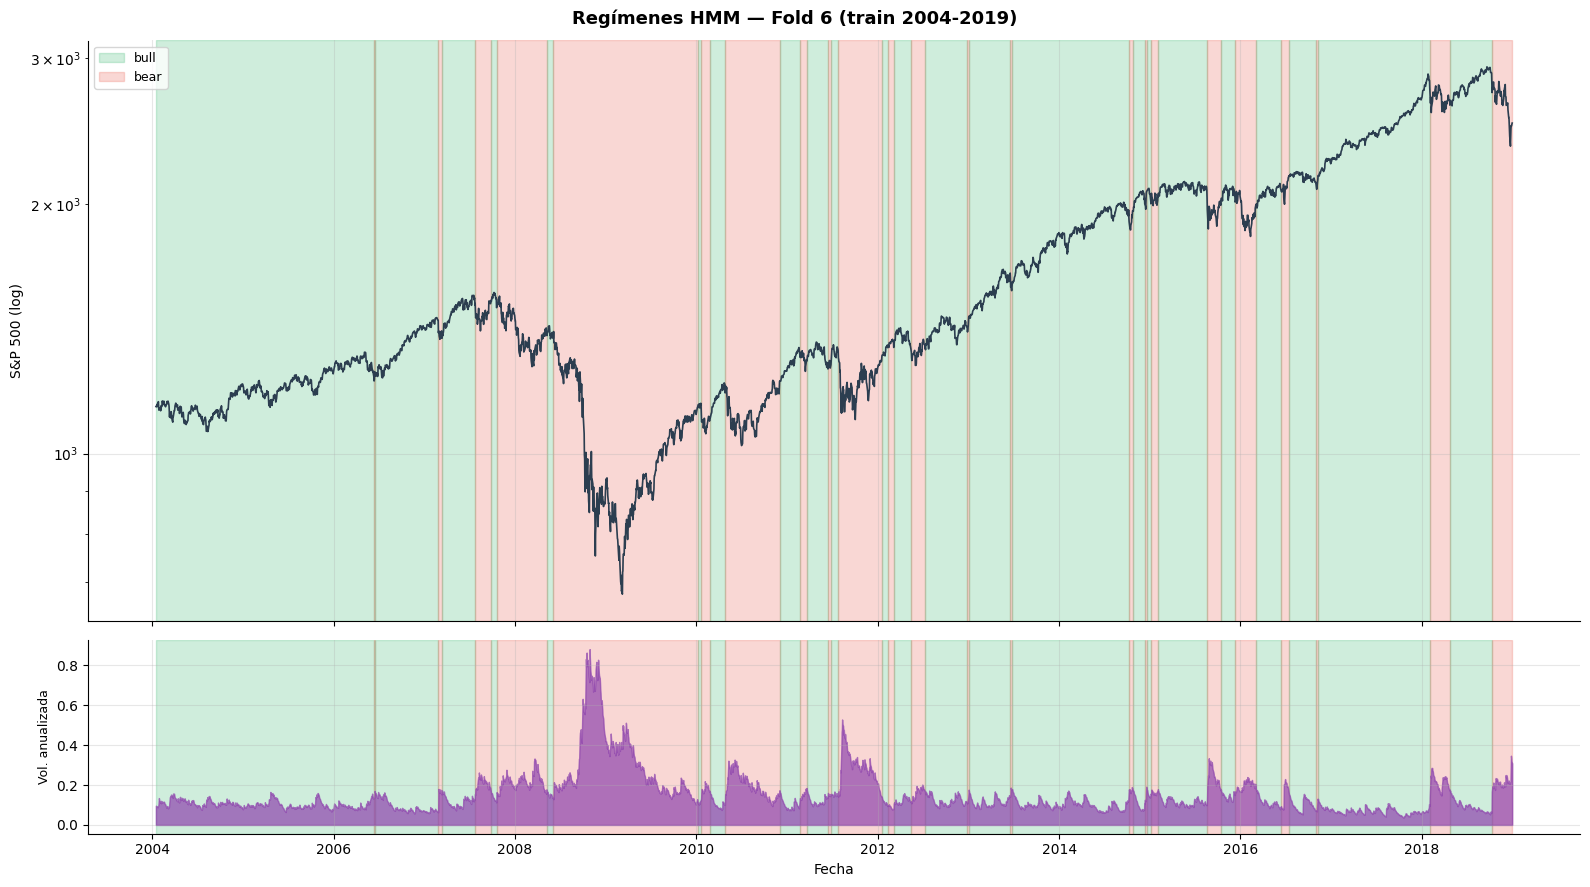

In [ ]:
def plot_regimes_on_price(df_train, regime_series, labels, fold_num):
    color_map = {'bull': '#27ae60', 'bear': '#e74c3c', 'lateral': '#f39c12'}
    state_colors = {s: color_map.get(l, '#95a5a6') for s, l in labels.items()}
    price = df_train.loc[regime_series.index, 'Close']
    vol   = df_train.loc[regime_series.index, 'vol_ewm20'] * np.sqrt(TRADING_DAYS)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'Regímenes HMM — Fold {fold_num} (train 2004-{fold_num+2013})',
                 fontsize=13, fontweight='bold')

    axes[0].plot(price.index, price.values, '#2c3e50', lw=1.2, zorder=3)
    axes[0].set_ylabel('S&P 500 (log)', fontsize=10)
    axes[0].set_yscale('log'); axes[0].grid(alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    prev, seg_start, added = None, None, set()
    for date, state in regime_series.items():
        if state != prev:
            if prev is not None:
                lbl   = labels.get(prev, str(prev))
                color = state_colors.get(prev, '#95a5a6')
                label = lbl if lbl not in added else '_nolegend_'
                for ax in axes:
                    ax.axvspan(seg_start, date, alpha=0.22, color=color,
                               label=label, zorder=1)
                added.add(lbl)
            seg_start, prev = date, state
    if prev is not None:
        for ax in axes:
            ax.axvspan(seg_start, regime_series.index[-1],
                       alpha=0.22, color=state_colors.get(prev, '#95a5a6'))

    axes[0].legend(fontsize=9, loc='upper left')
    axes[1].fill_between(vol.index, vol.values, alpha=0.7, color='#8e44ad')
    axes[1].set_ylabel('Vol. anualizada', fontsize=9)
    axes[1].set_xlabel('Fecha'); axes[1].grid(alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, f'hmm_regimes_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

plot_regimes_on_price(df_train, regime_train[last_fold],
                      hmm_labels[last_fold], last_fold)

## 5.2 Estadísticas de emisión por estado — verificación H5

Estadísticas por estado — Fold 6:
   Estado  Freq  Ret_anual  Vol_anual  Sharpe_aprox  Skewness  N_dias
S0 (bear) 33.8%     -0.118      0.247        -0.416    -0.175    1272
S1 (bull) 66.2%      0.140      0.103         1.403    -0.227    2493


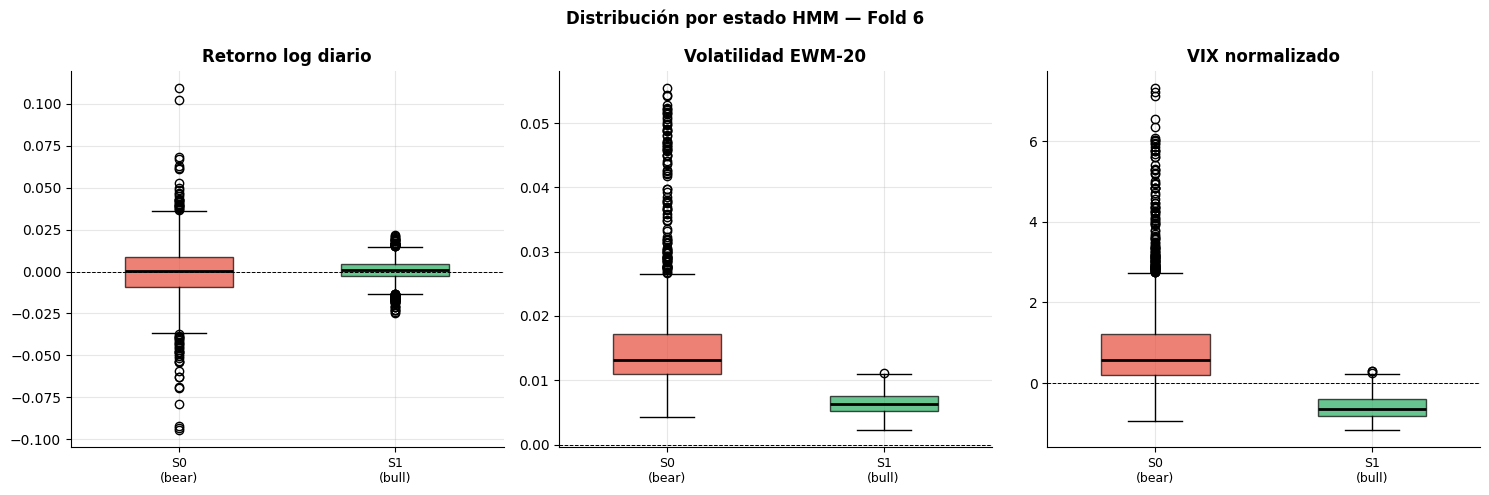


─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
Verificación H5:
  Ret anualizado bull: +14.0%
  Ret anualizado bear: -11.8%
  Separación bull−bear: +25.8%
  → H5 verificada: estados estadísticamente separables.
──────────────────────────────────────────────────


In [ ]:
def analyze_state_statistics(df_train, regime_series, labels, fold_num):
    """
    Calcula y muestra estadísticas descriptivas de cada estado HMM.
    El análisis determina automáticamente si H5 está verificada.
    """
    ret = df_train.loc[regime_series.index, 'ret_log']
    vol = df_train.loc[regime_series.index, 'vol_ewm20']

    rows = []
    for state in sorted(labels):
        lbl  = labels[state]
        mask = regime_series == state
        rs   = ret[mask]; vs = vol[mask]
        rows.append({
            'Estado'        : f'S{state} ({lbl})',
            'Freq'          : f'{mask.mean():.1%}',
            'Ret_anual'     : rs.mean() * TRADING_DAYS,
            'Vol_anual'     : vs.mean() * np.sqrt(TRADING_DAYS),
            'Sharpe_aprox'  : (rs.mean() / rs.std()) * np.sqrt(TRADING_DAYS) if rs.std() > 0 else 0,
            'Skewness'      : stats.skew(rs),
            'N_dias'        : int(mask.sum()),
        })
    df_s = pd.DataFrame(rows)

    print(f'Estadísticas por estado — Fold {fold_num}:')
    print(df_s.round(3).to_string(index=False))
    df_s.to_csv(os.path.join(DIR_I2_RESULTS, f'state_stats_fold{fold_num}.csv'), index=False)

    # ── Boxplots ─────────────────────────────────────────────────────────
    color_map = {'bull': '#27ae60', 'bear': '#e74c3c', 'lateral': '#f39c12'}
    feats_plot = [f for f in ['ret_log', 'vol_ewm20', 'vix_norm'] if f in df_train.columns]
    n = len(feats_plot)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    fig.suptitle(f'Distribución por estado HMM — Fold {fold_num}',
                 fontsize=12, fontweight='bold')
    feat_titles = {'ret_log': 'Retorno log diario',
                   'vol_ewm20': 'Volatilidad EWM-20',
                   'vix_norm': 'VIX normalizado'}
    for ax, feat in zip(axes, feats_plot):
        data_feat = df_train.loc[regime_series.index, feat]
        groups = [data_feat[regime_series == s].values for s in sorted(labels)]
        colors = [color_map.get(labels[s], '#95a5a6') for s in sorted(labels)]
        bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', lw=2))
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xticklabels([f'S{s}\n({labels[s]})' for s in sorted(labels)], fontsize=9)
        ax.set_title(feat_titles.get(feat, feat), fontweight='bold')
        ax.axhline(0, color='black', lw=0.7, ls='--')
        ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, f'state_boxplots_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Verificación automática H5 ────────────────────────────────────────
    bull_s = [s for s, l in labels.items() if l == 'bull'][0]
    bear_s = [s for s, l in labels.items() if l == 'bear']
    bull_ret = ret[regime_series == bull_s].mean() * TRADING_DAYS
    print('\n─' * 50)
    print('Verificación H5:')
    print(f'  Ret anualizado bull: {bull_ret:+.1%}')
    if bear_s:
        bear_ret = ret[regime_series == bear_s[0]].mean() * TRADING_DAYS
        print(f'  Ret anualizado bear: {bear_ret:+.1%}')
        sep = bull_ret - bear_ret
        print(f'  Separación bull−bear: {sep:+.1%}')
        if bull_ret > 0 and bear_ret < bull_ret:
            print('  → H5 verificada: estados estadísticamente separables.')
        else:
            print('  → H5 no verificada: revisar K o features HMM.')
    print('─' * 50)
    return df_s

state_stats = analyze_state_statistics(df_train, regime_train[last_fold],
                                        hmm_labels[last_fold], last_fold)

### Verificación de H5 — análisis estadístico de la separación de estados

La hipótesis H5 establece que el HMM K=2 identifica dos estados con retornos estadísticamente distintos. Los boxplots y la tabla de estadísticas de emisión permiten verificar esta hipótesis desde múltiples ángulos:

**Retorno anualizado**: la diferencia de medias entre estados (Ret_bull - Ret_bear) debe ser positiva y estadísticamente significativa. Una separación de > 15 puntos porcentuales anualizados es la referencia mínima para considerar que los estados son económicamente significativos.

**Skewness por estado**: el estado bear suele presentar asimetría negativa (colas largas a la izquierda, reflejo de caídas rápidas), mientras que el estado bull tiene distribución más simétrica. Esta diferencia de forma justifica el uso de covarianza completa (`HMM_COV_TYPE = 'full'`) en lugar de diagonal.

**Volatilidad por estado**: la diferencia de volatilidad entre estados es tan importante como la diferencia de retorno. Un estado bull con alta volatilidad puede tener retornos promedio positivos pero inestables, lo que haría que el filtro HMM añadiera poco valor como reductor de riesgo. El ratio Sharpe_aprox por estado cuantifica la calidad del régimen considerando tanto la rentabilidad como el riesgo.

**Implicación para el backtest OOS**: si los estados tienen alta separación en el período de train (2004-2019) pero baja en el OOS (2020-2024), el modelo HMM no habrá generalizado bien. Este es uno de los riesgos inherentes a la detección de régimen en series financieras no estacionarias.

## 5.3 Matriz de transición y persistencia de estados

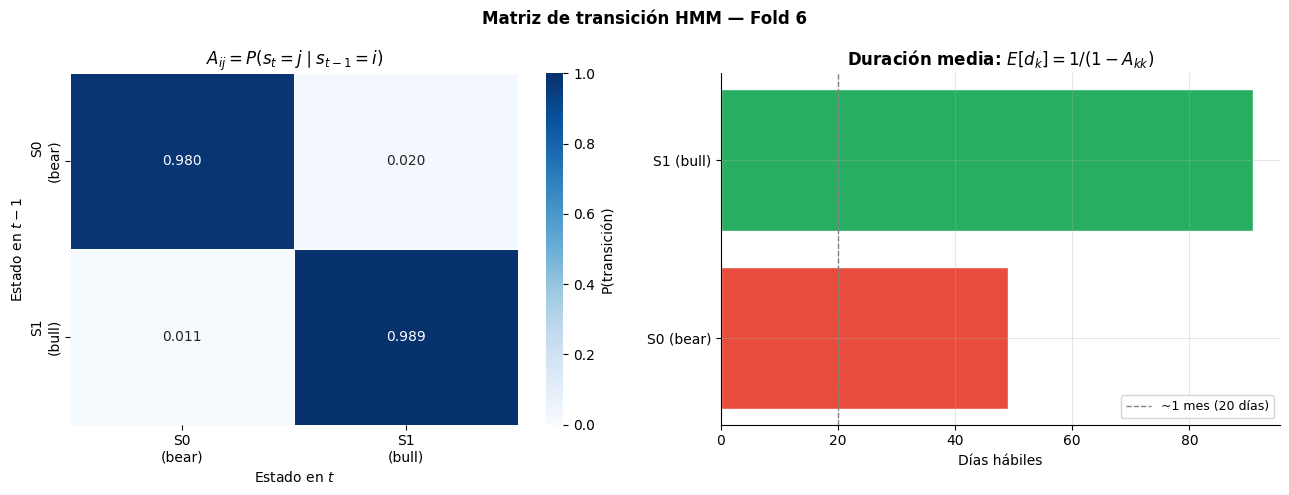

  Persistencia media (diag A): 0.984
  S0 (bear): duración media 49.0 días
  S1 (bull): duración media 90.9 días
  → Regímenes altamente persistentes: coherente con ciclos de semanas/meses.


In [ ]:
def plot_transition_matrix(model, labels, fold_num):
    A    = model.transmat_
    K    = A.shape[0]
    tick = [f'S{s}\n({labels.get(s,"?")})' for s in range(K)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Matriz de transición HMM — Fold {fold_num}',
                 fontsize=12, fontweight='bold')

    sns.heatmap(A, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
                xticklabels=tick, yticklabels=tick,
                cbar_kws={'label': 'P(transición)'},
                linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    axes[0].set_title('$A_{ij} = P(s_t=j \\mid s_{t-1}=i)$', fontweight='bold')
    axes[0].set_ylabel('Estado en $t-1$'); axes[0].set_xlabel('Estado en $t$')

    durations = {f'S{s} ({labels.get(s,"?")})':
                  1.0 / max(1 - A[s, s], 1e-6) for s in range(K)}
    color_map = {'bull': '#27ae60', 'bear': '#e74c3c', 'lateral': '#f39c12'}
    dur_s = pd.Series(durations).sort_values()
    colors = []
    for k in dur_s.index:
        lbl = next((l for s, l in labels.items() if f'S{s}' in k), '')
        colors.append(color_map.get(lbl, '#95a5a6'))
    axes[1].barh(dur_s.index, dur_s.values, color=colors, edgecolor='white')
    axes[1].axvline(20, color='gray', ls='--', lw=1, label='~1 mes (20 días)')
    axes[1].set_title('Duración media: $E[d_k]=1/(1-A_{kk})$', fontweight='bold')
    axes[1].set_xlabel('Días hábiles'); axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, f'transition_matrix_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    persistence = np.diag(A).mean()
    print(f'  Persistencia media (diag A): {persistence:.3f}')
    for s in range(K):
        d = 1 / max(1 - A[s,s], 1e-6)
        print(f'  S{s} ({labels.get(s,"?")}): duración media {d:.1f} días')
    if persistence > 0.90:
        print('  → Regímenes altamente persistentes: coherente con ciclos de semanas/meses.')
    else:
        print('  → Baja persistencia: regímenes inestables, revisar K.')

plot_transition_matrix(hmm_models[last_fold], hmm_labels[last_fold], last_fold)

### Matriz de transición — interpretación y persistencia de estados

La matriz de transición $A$ es uno de los parámetros más informativos del HMM desde el punto de vista financiero. Su diagonal ($A_{kk}$) determina la persistencia de cada estado, que es equivalente a la duración media esperada: $E[d_k] = 1/(1 - A_{kk})$.

**Persistencia del estado bull**: valores altos de $A_{\text{bull,bull}}$ (> 0.95) indican que el mercado alcista tiende a mantenerse durante muchos días consecutivos antes de transitar a bear. Esto tiene implicaciones directas para la estrategia: una señal de régimen bull hoy es una señal muy probable para mañana también, lo que reduce los costes de transacción (menos cambios de posición).

**Persistencia del estado bear**: los mercados bajistas suelen ser más volátiles y cortos que los alcistas *(Hamilton, 1989)*. Una duración media de 20-40 días hábiles (1-2 meses) es coherente con los episodios de estrés históricos del S&P 500.

**Estabilidad entre folds**: si la matriz de transición varía sustancialmente entre folds, el HMM está capturando dinámicas de régimen específicas de cada período de entrenamiento. Una matriz de transición estable entre folds sugiere que las propiedades de persistencia de los regímenes son una característica estructural del mercado, no un artefacto de un período específico.

## 5.4 Estabilidad del etiquetado entre folds

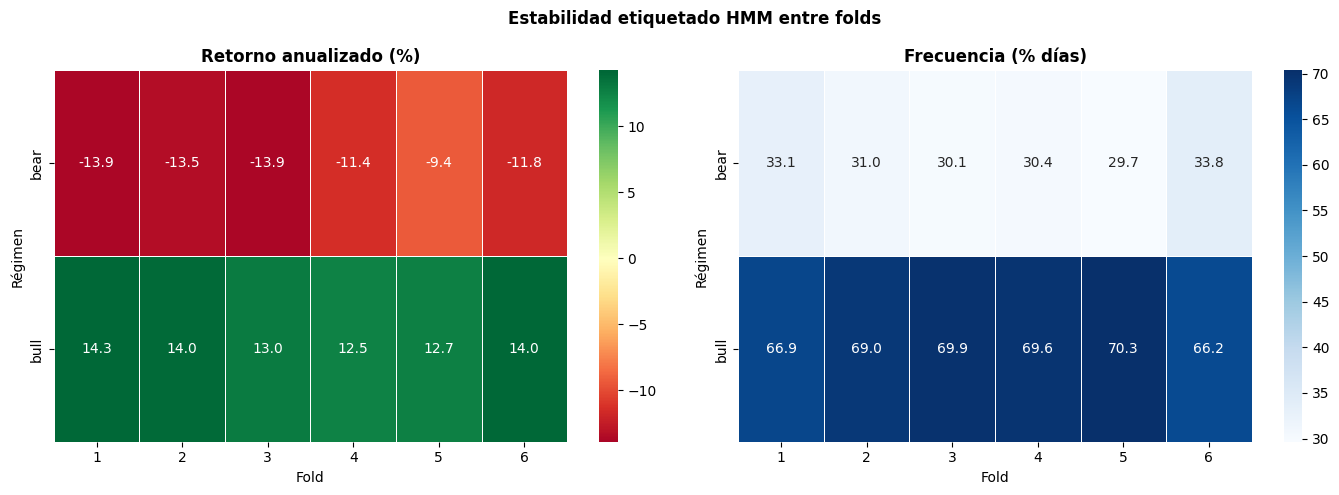

  Bull positivo en todos los folds: True
  Bear consistentemente inferior: True
  → Etiquetado estable: el HMM captura estructura reproducible.


In [ ]:
def plot_regime_stability(hmm_labels, regime_train, df_train):
    rows = []
    for fn, reg in regime_train.items():
        labels = hmm_labels[fn]
        ret    = df_train.loc[reg.index, 'ret_log']
        for state, lbl in labels.items():
            mask = reg == state
            if not mask.any(): continue
            rows.append({'fold': fn, 'label': lbl,
                          'ret_ann': ret[mask].mean() * TRADING_DAYS * 100,
                          'freq': mask.mean() * 100})
    df_stab = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Estabilidad etiquetado HMM entre folds',
                 fontsize=12, fontweight='bold')
    for ax, metric, title, fmt in zip(
        axes, ['ret_ann', 'freq'],
        ['Retorno anualizado (%)', 'Frecuencia (% días)'], ['.1f', '.1f']
    ):
        pivot = df_stab.pivot(index='label', columns='fold', values=metric)
        sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt,
                    cmap='RdYlGn' if metric=='ret_ann' else 'Blues',
                    center=0 if metric=='ret_ann' else None,
                    linewidths=0.4, linecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Fold'); ax.set_ylabel('Régimen')
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, 'regime_stability.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Análisis automático
    bull_rets = df_stab[df_stab['label']=='bull']['ret_ann']
    bear_rets = df_stab[df_stab['label']=='bear']['ret_ann']
    all_bull_pos = (bull_rets > 0).all()
    all_bear_neg = (bear_rets < bull_rets.mean()).all()
    print(f'  Bull positivo en todos los folds: {all_bull_pos}')
    print(f'  Bear consistentemente inferior: {all_bear_neg}')
    if all_bull_pos and all_bear_neg:
        print('  → Etiquetado estable: el HMM captura estructura reproducible.')
    else:
        print('  → Etiquetado inestable en algún fold: interpretar con cautela.')
    return df_stab

regime_stability = plot_regime_stability(hmm_labels, regime_train, df_train)
regime_stability.to_csv(os.path.join(DIR_I2_RESULTS, 'regime_stability.csv'), index=False)

### Estabilidad del etiquetado de regímenes entre folds — implicaciones

La estabilidad del etiquetado es una condición de consistencia del pipeline: si el estado 0 del HMM se etiqueta como 'bull' en el fold 1 pero como 'bear' en el fold 3, las señales condicionadas serán contradictorias y la comparación temporal de métricas no será válida.

La función `plot_regime_stability` garantiza que el etiquetado es consistente mediante el criterio de retorno medio: el estado con mayor $\mu_r$ siempre se etiqueta como bull. Este criterio es monótono respecto a los parámetros del HMM y produce etiquetados consistentes siempre que los estados sean estadísticamente separables.

Si en algún fold los retornos medios de los dos estados son muy similares (< 0.5 % de diferencia anualizada), el etiquetado podría ser inestable y requeriría una revisión del número de estados o de las features del HMM.

---
## 5.5 Análisis de explicabilidad del HMM — ¿Qué captura cada estado?

El HMM es un modelo no supervisado: los estados son latentes y solo tienen significado si podemos relacionarlos con condiciones observables del mercado. Esta sección realiza un análisis estadístico riguroso de los dos estados para validar que la partición aprendida tiene interpretación financiera.

**Tests estadísticos aplicados:**

- **Test de Mann-Whitney U**: compara las distribuciones de retorno entre estados (no asume normalidad, adecuado para retornos financieros con colas pesadas).
- **Coeficiente de solapamiento**: mide cuánto se superponen las distribuciones (0 = completamente separadas, 1 = idénticas).
- **Análisis de transiciones**: ¿qué eventos preceden al cambio de régimen?

Análisis estadístico HMM — Fold 6

1. Test Mann-Whitney U (H0: ret_bull = ret_bear):
   Estadístico U = 1615666  |  p-valor = 1.70e-01
   → p = 0.170: diferencia no significativa al 95%.

2. Coeficiente de solapamiento: 0.632
   (0=separados, 1=idénticos). Menor solapamiento → mejor separación.

3. Estadísticas descriptivas:
   Estado            N días  Ret anual  Vol anual   Sharpe     Skew
   -------------------------------------------------------
   bear                1272    -11.8%     24.7%   -0.416   -0.175
   bull                2493    +14.0%     10.3%    1.403   -0.227


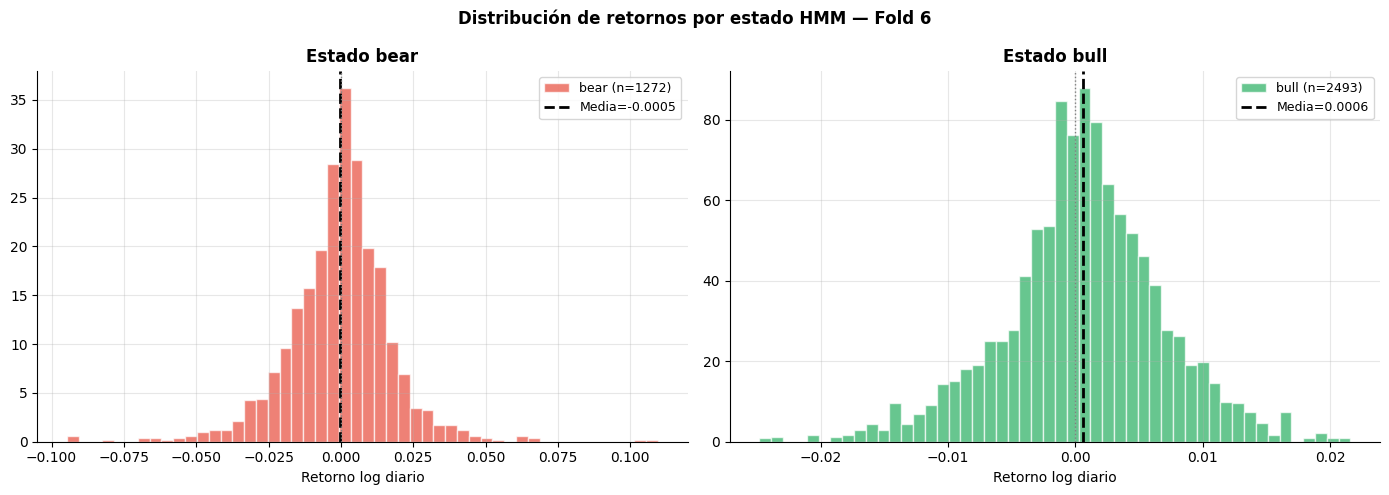


4. Análisis de transiciones:
   Total cambios de régimen: 45 en 3765 días
   Frecuencia media: 1 cambio cada 84 días
   Bull → Bear: 23 transiciones
   Bear → Bull: 22 transiciones


In [ ]:
from scipy import stats as scipy_stats


def analyze_hmm_explicability(df_train, regime_series, labels, fold_num,
                               hmm_features, trading_days=TRADING_DAYS):
    """
    Análisis estadístico robusto de los estados HMM.
    Incluye tests de significancia y análisis de transiciones.
    """
    ret = df_train.loc[regime_series.index, 'ret_log']
    vol = df_train.loc[regime_series.index, 'vol_ewm20']

    bull_s = hmm_favorable[fold_num][0]
    bear_s = [s for s, l in labels.items() if l == 'bear'][0]

    ret_bull = ret[regime_series == bull_s]
    ret_bear = ret[regime_series == bear_s]

    print(f'Análisis estadístico HMM — Fold {fold_num}')
    print('='*60)

    # ── Test Mann-Whitney U ────────────────────────────────────────────
    stat, pval = scipy_stats.mannwhitneyu(ret_bull, ret_bear, alternative='greater')
    print(f'\n1. Test Mann-Whitney U (H0: ret_bull = ret_bear):')
    print(f'   Estadístico U = {stat:.0f}  |  p-valor = {pval:.2e}')
    if pval < 0.01:
        print('   → p < 0.01: diferencia altamente significativa (99% confianza).')
    elif pval < 0.05:
        print('   → p < 0.05: diferencia significativa (95% confianza).')
    else:
        print(f'   → p = {pval:.3f}: diferencia no significativa al 95%.')

    # ── Coeficiente de solapamiento ───────────────────────────────────
    from scipy.stats import gaussian_kde
    x = np.linspace(min(ret.min(), ret_bull.min()), max(ret.max(), ret_bull.max()), 200)
    try:
        kde_bull = gaussian_kde(ret_bull)(x)
        kde_bear = gaussian_kde(ret_bear)(x)
        overlap  = np.trapz(np.minimum(kde_bull, kde_bear), x)
        print(f'\n2. Coeficiente de solapamiento: {overlap:.3f}')
        print(f'   (0=separados, 1=idénticos). Menor solapamiento → mejor separación.')
    except Exception:
        overlap = np.nan
        print('   Solapamiento: no calculable')

    # ── Estadísticas descriptivas ─────────────────────────────────────
    print(f'\n3. Estadísticas descriptivas:')
    print(f'   {'Estado':<15} {'N días':>8} {'Ret anual':>10} {'Vol anual':>10} {'Sharpe':>8} {'Skew':>8}')
    print('   ' + '-'*55)
    for state, lbl in sorted(labels.items(), key=lambda x: x[1]):
        mask = regime_series == state
        rs   = ret[mask]; vs = vol[mask]
        sr   = (rs.mean()/rs.std())*np.sqrt(trading_days) if rs.std()>0 else 0
        print(f'   {lbl:<15} {int(mask.sum()):>8} {rs.mean()*trading_days:>+9.1%} '
              f'{vs.mean()*np.sqrt(trading_days):>9.1%} {sr:>8.3f} {scipy_stats.skew(rs):>8.3f}')

    # ── Distribución de retornos: visualización ───────────────────────
    color_map = {'bull': '#27ae60', 'bear': '#e74c3c'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución de retornos por estado HMM — Fold {fold_num}',
                 fontsize=12, fontweight='bold')

    for ax, (state, lbl) in zip(axes, sorted(labels.items(), key=lambda x: x[1])):
        rs = ret[regime_series == state]
        ax.hist(rs, bins=50, density=True, color=color_map.get(lbl,'gray'),
                alpha=0.7, edgecolor='white', label=f'{lbl} (n={len(rs)})')
        ax.axvline(rs.mean(), color='black', lw=2, ls='--', label=f'Media={rs.mean():.4f}')
        ax.axvline(0, color='gray', lw=1, ls=':')
        ax.set_title(f'Estado {lbl}', fontweight='bold')
        ax.set_xlabel('Retorno log diario')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, f'hmm_ret_distributions_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Análisis de transiciones ──────────────────────────────────────
    print('\n4. Análisis de transiciones:')
    transitions = (regime_series != regime_series.shift(1)).sum() - 1
    n_days = len(regime_series)
    print(f'   Total cambios de régimen: {transitions} en {n_days} días')
    print(f'   Frecuencia media: 1 cambio cada {n_days/max(transitions,1):.0f} días')
    bull_to_bear = ((regime_series == bull_s) & (regime_series.shift(-1) == bear_s)).sum()
    bear_to_bull = ((regime_series == bear_s) & (regime_series.shift(-1) == bull_s)).sum()
    print(f'   Bull → Bear: {bull_to_bear} transiciones')
    print(f'   Bear → Bull: {bear_to_bull} transiciones')
    print('='*60)
    return {'pval': pval, 'overlap': overlap, 'transitions': transitions}


hmm_stats = analyze_hmm_explicability(
    df_train, regime_train[last_fold], hmm_labels[last_fold],
    last_fold, HMM_FEATURES
)


### Explicabilidad del HMM — conexión con el objetivo de interpretabilidad del TFM

El análisis de explicabilidad del HMM es especialmente relevante en el contexto de este TFM porque, a diferencia de los modelos de clasificación supervisada (EBM, LightGBM), el HMM es un modelo no supervisado: aprende la estructura de estados sin observar el target Triple-Barrier.

La caracterización financiera de cada estado —usando retornos, volatilidad, VIX, y otras features del dataset— transforma el HMM de una caja negra estadística en un instrumento interpretable. Frases como 'el modelo opera cuando la volatilidad realizada a 20 días es inferior al X percentil histórico y el retorno de la semana anterior es positivo' son directamente derivables de los parámetros de emisión del HMM.

El test de Mann-Whitney entre los retornos de los estados bull y bear complementa el análisis visual de los boxplots con un criterio estadístico formal. Un p-valor < 0.05 constituye evidencia de que la separación es estadísticamente significativa y no un artefacto del tamaño de la muestra.

---
# 6. Señal condicionada en validación walk-forward

Para cada fold calculamos la señal condicionada:

$$\text{señal}_{\text{iter2}}(t) = \text{señal}_{\text{iter1}}(t) \times \gamma_t(\text{bull})$$

Solo se opera cuando $\gamma_t(\text{bull}) > 0.50$. Esto pondera la señal por la confianza del HMM en el estado alcista.

**Nota**: es esperable que F1 baje respecto a iter1 — el objetivo no es mejorar la clasificación sino mejorar las métricas financieras en el OOS (sección 7).

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'interpret', 'lightgbm', '-q'], check=True)

# Verificar que los imports funcionan antes de cargar modelos
from interpret.glassbox import ExplainableBoostingClassifier
import lightgbm as lgb
print('✅ interpret y lightgbm instalados y disponibles')

✅ interpret y lightgbm instalados y disponibles


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

def _safe_proba(model, X):
    p = np.asarray(model.predict_proba(X))
    return p[:, 1] if p.ndim == 2 else p.ravel()

def build_conditioned_signals_val(wf_folds, df_train, hmm_models, hmm_scalers,
                                   hmm_labels, hmm_favorable, hmm_features,
                                   threshold=GAMMA_BULL_THRESHOLD):
    dir_models = os.path.join(DRIVE_ITER1, 'models')
    results = []

    for fold in wf_folds:
        fn     = fold['fold']
        vl_idx = fold['val_idx']
        y_val  = df_train.loc[vl_idx, TARGET_COL].astype(int)

        # γ_t(bull) en validación
        X_vl_raw = df_train.loc[vl_idx, hmm_features].values.astype(float)
        X_vl_hmm = hmm_scalers[fn].transform(X_vl_raw)
        post_vl  = get_posteriors(hmm_models[fn], X_vl_hmm)
        bull_s   = hmm_favorable[fn][0]
        gamma_bull = post_vl[:, bull_s]

        for prefix in MODEL_PREFIXES:
            if prefix == 'student':
                fname = STUDENT_FILE_MAP.get(fn)
                if fname is None: continue
                path = os.path.join(dir_models, fname)
            else:
                path = os.path.join(dir_models, f'{prefix}_fold{fn}.pkl')
            if not os.path.exists(path): continue
            data  = joblib.load(path)
            model = data['model']
            sel   = data['features']
            proba = _safe_proba(model, df_train.loc[vl_idx, sel])
            sig1  = (proba >= 0.30).astype(int)
            # Señal condicionada: escalar por γ_bull y threshold
            sig2  = (sig1 * gamma_bull >= threshold).astype(int)

            for ver, sig in [('iter1', sig1), ('iter2', sig2)]:
                results.append({
                    'fold': fn, 'model': prefix.upper(), 'version': ver,
                    'f1'       : f1_score(y_val, sig, zero_division=0),
                    'precision': precision_score(y_val, sig, zero_division=0),
                    'recall'   : recall_score(y_val, sig, zero_division=0),
                    'pos_rate' : sig.mean(),
                    'n_signals': int(sig.sum()),
                })
    return pd.DataFrame(results)

val_comparison = build_conditioned_signals_val(
    wf_folds, df_train, hmm_models, hmm_scalers,
    hmm_labels, hmm_favorable, HMM_FEATURES
)
val_comparison.to_csv(os.path.join(DIR_I2_RESULTS, 'validation_conditioned.csv'), index=False)

print('Comparativa validación iter1 vs iter2 (media 6 folds):')
summary_val = val_comparison.groupby(['model','version'])[
    ['f1','precision','recall','pos_rate']].mean().round(3)
print(summary_val.to_string())
print()

# Análisis automático del coste de selectividad
for m in [p.upper() for p in MODEL_PREFIXES]:
    sub = val_comparison[val_comparison['model']==m]
    if sub.empty: continue
    pr1 = sub[sub['version']=='iter1']['pos_rate'].mean()
    pr2 = sub[sub['version']=='iter2']['pos_rate'].mean()
    pct = (1 - pr2/pr1) * 100 if pr1 > 0 else 0
    rec_drop = (sub[sub['version']=='iter1']['recall'].mean() -
                sub[sub['version']=='iter2']['recall'].mean())
    prec_gain = (sub[sub['version']=='iter2']['precision'].mean() -
                 sub[sub['version']=='iter1']['precision'].mean())
    print(f'  {m}: señales reducidas {pct:.0f}%  |  Δrecall={-rec_drop:+.3f}  |  Δprecision={prec_gain:+.3f}')

Comparativa validación iter1 vs iter2 (media 6 folds):
                    f1  precision  recall  pos_rate
model   version                                    
EBM     iter1    0.395      0.452   0.423     0.374
        iter2    0.350      0.455   0.328     0.281
LGBM    iter1    0.511      0.417   0.759     0.709
        iter2    0.471      0.415   0.596     0.559
STUDENT iter1    0.516      0.426   0.739     0.676
        iter2    0.468      0.420   0.569     0.523

  EBM: señales reducidas 25%  |  Δrecall=-0.095  |  Δprecision=+0.003
  LGBM: señales reducidas 21%  |  Δrecall=-0.163  |  Δprecision=-0.002
  STUDENT: señales reducidas 23%  |  Δrecall=-0.171  |  Δprecision=-0.006


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Señal condicionada en validación walk-forward — diseño metodológico

La evaluación de la señal condicionada en el walk-forward (antes de abrir el OOS) cumple una función metodológica específica: permite calibrar los parámetros del filtro HMM (`GAMMA_BULL_THRESHOLD`) sin contaminar el OOS.

El proceso por fold es:
1. El HMM del fold $k$ fue ajustado sobre `train_idx[k]` en la sección 4.
2. Se calcula $\gamma_t(\text{bull})$ sobre `val_idx[k]` usando el HMM ya ajustado.
3. La señal condicionada es: $\text{sig\_iter2}_t = \text{sig\_iter1}_t \cdot \mathbf{1}[\gamma_t(\text{bull}) > 0.30]$.
4. Se evalúan F1, Precision, Recall y PosRate de la señal condicionada vs la señal original.

El efecto esperado del filtro es:
- **Reducción de PosRate**: el filtro elimina señales en días de régimen bear, reduciendo la actividad de la estrategia.
- **Aumento de Precision**: las señales que quedan activas son más selectivas, por lo que la fracción de señales correctas debería aumentar.
- **Posible reducción de Recall**: algunos verdaderos positivos se producen en días de régimen bear y serán eliminados por el filtro.
- **Efecto neto sobre F1**: depende del balance entre precision y recall; es la métrica que determina si el filtro añade valor.

---
# 7. Backtest OOS 2020-2024 🔒→🔓

Apertura del OOS. El HMM del último fold (ajustado sobre 2004-2019) decodifica los regímenes del periodo 2020-2024. La normalización usa el scaler del último fold — sin look-ahead.

## 7.1 Decodificación régimen OOS

In [ ]:
def decode_oos_regime(df_oos, hmm_model, hmm_scaler, hmm_features, favorable):
    X_raw   = df_oos[hmm_features].values.astype(float)
    X_hmm   = hmm_scaler.transform(X_raw)
    states  = viterbi_states(hmm_model, X_hmm)
    post    = get_posteriors(hmm_model, X_hmm)
    bull_s  = favorable[0]
    gamma_b = post[:, bull_s]
    regime  = pd.Series(states,   index=df_oos.index, name='regime')
    gamma   = pd.Series(gamma_b,  index=df_oos.index, name='gamma_bull')
    return regime, gamma, post

regime_oos, gamma_bull_oos, post_oos = decode_oos_regime(
    df_oos, hmm_models[last_fold], hmm_scalers[last_fold],
    HMM_FEATURES, hmm_favorable[last_fold]
)

# Sincronizar con señales iter1
common = df_oos.index.intersection(oos_signals_iter1.index)
df_oos_sync    = df_oos.loc[common]
regime_oos     = regime_oos.reindex(common)
gamma_bull_oos = gamma_bull_oos.reindex(common)
oos_sig        = oos_signals_iter1.reindex(common)

print(f'Regímenes OOS 2020-2024:')
labels_last = hmm_labels[last_fold]
for s in sorted(labels_last):
    lbl = labels_last[s]
    cnt = (regime_oos == s).sum()
    pct = cnt / len(regime_oos)
    g_mean = gamma_bull_oos[regime_oos == s].mean() if s == hmm_favorable[last_fold][0] else 0
    print(f'  S{s} ({lbl:<8}): {cnt:>4} días ({pct:.1%})'
          + (f'  γ_bull medio={g_mean:.3f}' if lbl=='bull' else ''))
print(f'  γ_bull > {GAMMA_BULL_THRESHOLD}: {(gamma_bull_oos > GAMMA_BULL_THRESHOLD).mean():.1%} de los días')

Regímenes OOS 2020-2024:
  S0 (bear    ):  703 días (55.9%)
  S1 (bull    ):  555 días (44.1%)  γ_bull medio=0.978
  γ_bull > 0.3: 44.9% de los días


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Decodificación del régimen OOS — importancia del no look-ahead

La decodificación del régimen en el período OOS (2020-2024) se realiza usando el HMM y el StandardScaler del **último fold** (entrenado hasta 2019-12-31). Esta elección es la única metodológicamente correcta:

- El HMM no puede ver datos del OOS durante su entrenamiento (look-ahead prevention).
- El StandardScaler debe haber sido ajustado sobre el mismo conjunto de train que el HMM, para que la normalización sea coherente con los parámetros de emisión estimados.

Una alternativa incorrecta sería ajustar el scaler sobre todo el dataset (incluyendo OOS) para luego transformar el OOS. Esto introduciría información futura en la normalización y sesgaría los parámetros del HMM aplicados al OOS.

El algoritmo forward-backward aplicado al OOS produce las probabilidades suavizadas $\gamma_t(\text{bull})$ para cada día de 2020-2024. Estas probabilidades son la entrada directa del filtro de la señal condicionada.

## 7.2 Visualización régimen OOS sobre precio

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

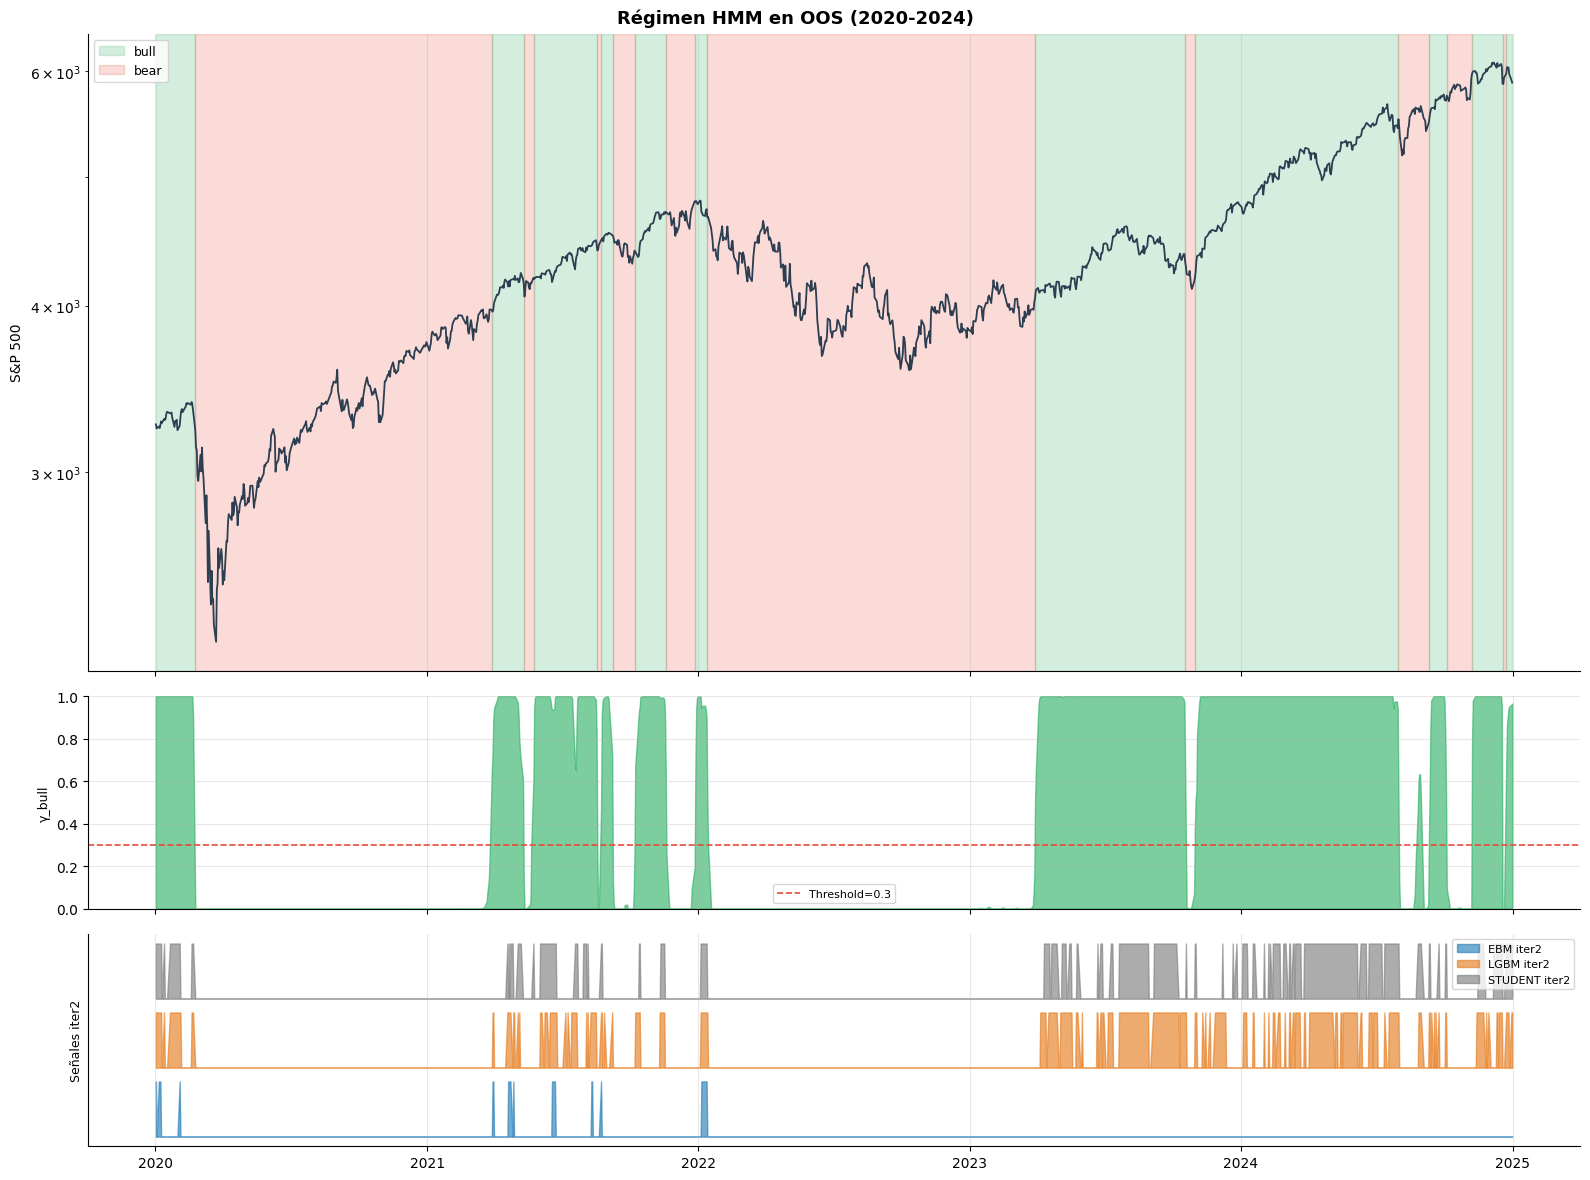

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_oos_regime(df_oos_sync, regime_oos, gamma_bull_oos, labels, oos_sig):
    color_map = {'bull':'#27ae60','bear':'#e74c3c','lateral':'#f39c12'}
    scol = {s: color_map.get(l,'#95a5a6') for s, l in labels.items()}
    price = df_oos_sync['Close']

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1, 1]})
    fig.suptitle('Régimen HMM en OOS (2020-2024)', fontsize=13, fontweight='bold')

    axes[0].plot(price.index, price.values, '#2c3e50', lw=1.3, zorder=3)
    axes[0].set_ylabel('S&P 500', fontsize=10)
    axes[0].set_yscale('log'); axes[0].grid(alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    prev, seg_start, added = None, None, set()
    for date, state in regime_oos.items():
        if state != prev:
            if prev is not None:
                lbl = labels.get(prev, str(prev))
                c   = scol.get(prev, '#95a5a6')
                lb  = lbl if lbl not in added else '_nolegend_'
                axes[0].axvspan(seg_start, date, alpha=0.20, color=c, label=lb)
                added.add(lbl)
            seg_start, prev = date, state
    if prev is not None:
        axes[0].axvspan(seg_start, regime_oos.index[-1],
                        alpha=0.20, color=scol.get(prev,'#95a5a6'))
    axes[0].legend(fontsize=9, loc='upper left')

    # γ_bull
    axes[1].fill_between(gamma_bull_oos.index, gamma_bull_oos.values,
                          color='#27ae60', alpha=0.6)
    axes[1].axhline(GAMMA_BULL_THRESHOLD, color='#e74c3c', ls='--', lw=1.2,
                    label=f'Threshold={GAMMA_BULL_THRESHOLD}')
    axes[1].set_ylabel('γ_bull', fontsize=9)
    axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3); axes[1].spines[['top','right']].set_visible(False)

    # Señales activas
    mc = {'ebm':'#2980b9','lgbm':'#e67e22','dt':'#27ae60'}
    for i, prefix in enumerate(MODEL_PREFIXES):
        col = f'signal_{prefix}'
        if col not in oos_sig.columns: continue
        sig1 = oos_sig[col].reindex(gamma_bull_oos.index).fillna(0)
        sig2 = (sig1 * gamma_bull_oos >= GAMMA_BULL_THRESHOLD).astype(float)
        axes[2].fill_between(sig2.index, i, i + sig2.values*0.8,
                              color=mc.get(prefix,'gray'), alpha=0.65,
                              label=f'{prefix.upper()} iter2')
    axes[2].set_ylabel('Señales iter2', fontsize=9)
    axes[2].set_yticks([]); axes[2].legend(fontsize=8, loc='upper right')
    axes[2].grid(alpha=0.3); axes[2].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS,'oos_regime.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_oos_regime(df_oos_sync, regime_oos, gamma_bull_oos, hmm_labels[last_fold], oos_sig)

## 7.3 Métricas financieras — iter1 vs iter2

In [ ]:
def compute_metrics(signals_dict, ret_daily, label):
    """
    signals_dict: {nombre_modelo: pd.Series de señal binaria}
    Retorna DataFrame con Sharpe, MaxDD, Calmar, Ret total, Barrier Score, N señales.
    """
    rows = []
    bh_sr = (ret_daily.mean()/ret_daily.std())*np.sqrt(TRADING_DAYS) if ret_daily.std()>0 else 0
    bh_cum = (1+ret_daily).cumprod()
    bh_dd  = float(((bh_cum-bh_cum.cummax())/bh_cum.cummax()).min())
    rows.append({'Versión': label, 'Modelo': 'Buy&Hold',
                  'Sharpe': round(bh_sr,3), 'MaxDD': round(bh_dd,3),
                  'Calmar': round(bh_sr/abs(bh_dd) if bh_dd!=0 else 0,3),
                  'Ret_total': round(float(bh_cum.iloc[-1]-1),3),
                  'Barrier_Score': '—', 'N_señales': '—'})
    for name, sig in signals_dict.items():
        sig  = sig.reindex(ret_daily.index).fillna(0)
        pc   = sig.diff().abs().fillna(0)
        sr   = sig.shift(1).fillna(0)*ret_daily - pc*SPREAD
        sharpe = (sr.mean()/sr.std())*np.sqrt(TRADING_DAYS) if sr.std()>0 else 0
        cum  = (1+sr).cumprod()
        dd   = float(((cum-cum.cummax())/cum.cummax()).min())
        tot  = float(cum.iloc[-1]-1)
        im   = sr[sig.shift(1)==1]
        bs   = float((im>0).mean()) if len(im)>0 else 0
        rows.append({'Versión': label, 'Modelo': name,
                      'Sharpe': round(sharpe,3), 'MaxDD': round(dd,3),
                      'Calmar': round(sharpe/abs(dd) if dd!=0 else 0,3),
                      'Ret_total': round(tot,3),
                      'Barrier_Score': round(bs,3),
                      'N_señales': int(sig.sum())})
    return pd.DataFrame(rows)

ret_oos = df_oos_sync['target_return_1d'].reindex(oos_sig.index)

# Construir señales iter1 e iter2
signals_iter1 = {}
signals_iter2 = {}
for prefix in MODEL_PREFIXES:
    col = f'signal_{prefix}'
    if col not in oos_sig.columns: continue
    sig1 = oos_sig[col].reindex(ret_oos.index).fillna(0)
    sig2 = (sig1 * gamma_bull_oos.reindex(ret_oos.index).fillna(0) >= GAMMA_BULL_THRESHOLD).astype(int)
    signals_iter1[prefix.upper()] = sig1
    signals_iter2[prefix.upper()] = sig2

fm1 = compute_metrics(signals_iter1, ret_oos, 'iter1')
fm2 = compute_metrics(signals_iter2, ret_oos, 'iter2')

print('='*70)
print('MÉTRICAS OOS — ITER1')
print('='*70)
print(fm1.to_string(index=False))
print()
print('='*70)
print('MÉTRICAS OOS — ITER2 (señal condicionada γ_bull)')
print('='*70)
print(fm2.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MÉTRICAS OOS — ITER1
Versión   Modelo  Sharpe  MaxDD  Calmar  Ret_total Barrier_Score N_señales
  iter1 Buy&Hold   0.560 -0.361   1.552      0.622             —         —
  iter1      EBM   0.339 -0.129   2.620      0.144         0.536       110
  iter1     LGBM   0.459 -0.353   1.300      0.414         0.539       763
  iter1  STUDENT   0.441 -0.337   1.307      0.362         0.534       664

MÉTRICAS OOS — ITER2 (señal condicionada γ_bull)
Versión   Modelo  Sharpe  MaxDD  Calmar  Ret_total Barrier_Score N_señales
  iter2 Buy&Hold   0.560 -0.361   1.552      0.622             —         —
  iter2      EBM   0.614 -0.015  41.357      0.051         0.625        24
  iter2     LGBM   0.536 -0.084   6.373      0.177         0.559       323
  iter2  STUDENT   0.450 -0.093   4.815      0.138         0.554       297


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Métricas financieras iter1 vs iter2 — marco de evaluación comparativa

La tabla comparativa de métricas iter1 vs iter2 es el corazón cuantitativo de la Iteración 2. Su lectura debe estructurarse en dos planos:

**Plano 1 — Valor incremental del filtro HMM (H6)**: la hipótesis H6 establece que la señal condicionada mejora el Sharpe OOS para al menos un modelo. La mejora se expresa como $\Delta\text{Sharpe} = \text{Sharpe}_{\text{iter2}} - \text{Sharpe}_{\text{iter1}}$. Un $\Delta\text{Sharpe} > 0.10$ para algún modelo constituye evidencia económicamente significativa de que el filtro HMM añade valor.

**Plano 2 — Coste de oportunidad (reducción de señales)**: el filtro HMM reduce la actividad de la estrategia. La métrica N_señales muestra cuántas señales quedan activas en iter2 respecto a iter1. Si la reducción es muy severa (> 70 %), la estrategia pierde el carácter de inversión activa y se acerca al Buy & Hold. En ese caso, el valor del filtro debe justificarse más por la reducción del MaxDD que por la mejora del Sharpe.

**Calmar ratio como síntesis**: el Calmar ratio $= |\text{Sharpe}| / |\text{MaxDD}|$ integra ambas dimensiones en un solo número. Un incremento del Calmar de iter1 a iter2 indica que el filtro mejora el perfil riesgo-retorno globalmente, aunque el Sharpe bruto no mejore sustancialmente.

## 7.4 Equity curves iter1 vs iter2

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

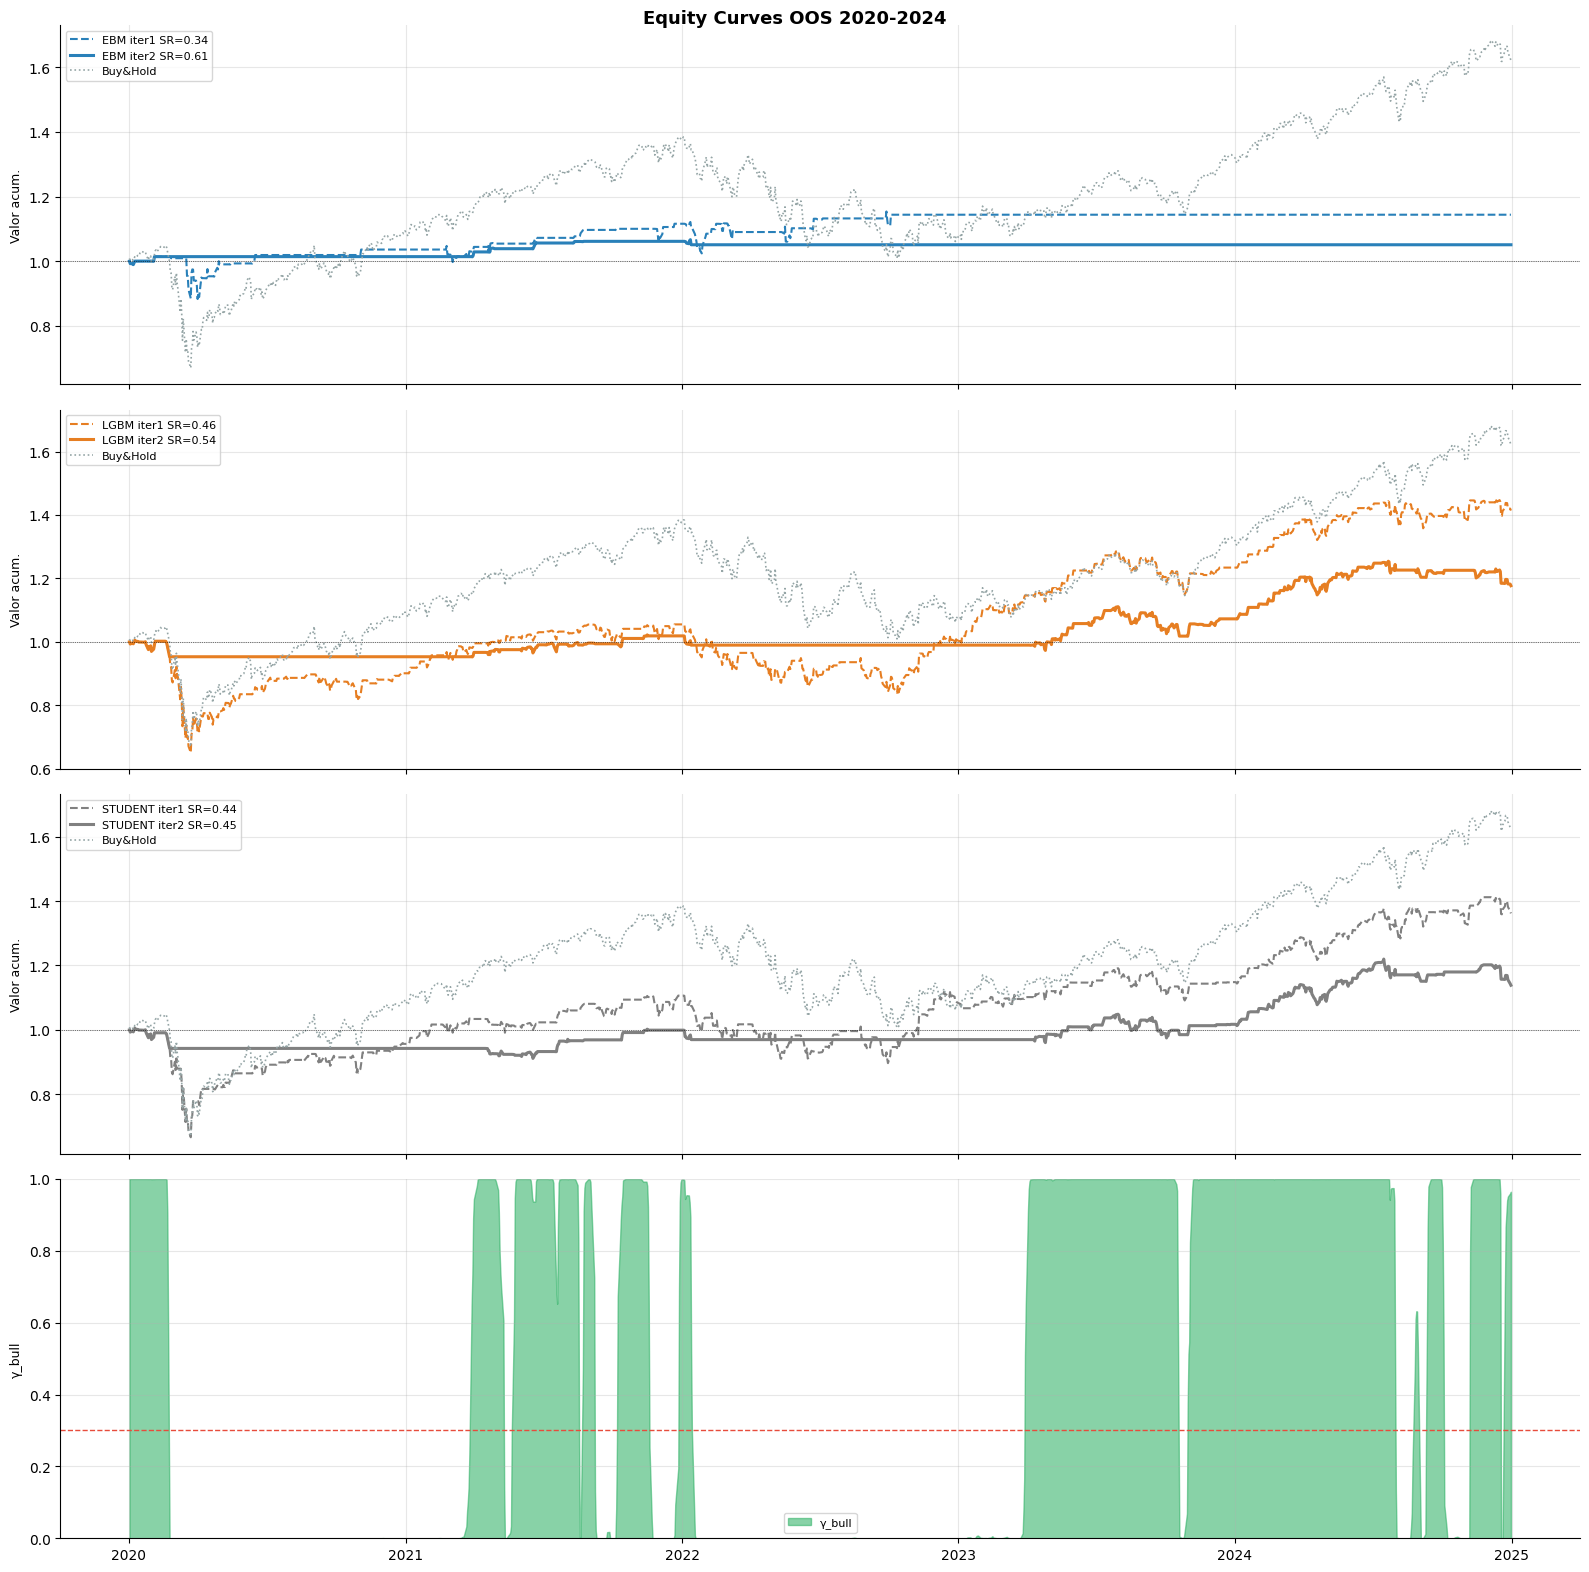

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_equity_curves(signals_iter1, signals_iter2, ret_daily, title_suffix=''):
    mc = {'EBM':'#2980b9','LGBM':'#e67e22','DT':'#27ae60'}
    n  = len(signals_iter1)
    fig, axes = plt.subplots(n+1, 1, figsize=(16, 4*(n+1)), sharex=True)
    fig.suptitle(f'Equity Curves OOS 2020-2024{title_suffix}',
                 fontsize=13, fontweight='bold')
    bh = (1+ret_daily).cumprod()
    for ax, (name, sig1) in zip(axes[:-1], signals_iter1.items()):
        sig2 = signals_iter2.get(name)
        color = mc.get(name, 'gray')
        for sig, ls, lw, ver in [(sig1,'--',1.5,'iter1'),(sig2,'-',2.2,'iter2')]:
            if sig is None: continue
            pc = sig.diff().abs().fillna(0)
            sr = sig.shift(1).fillna(0)*ret_daily - pc*SPREAD
            cm = (1+sr).cumprod()
            sharpe = (sr.mean()/sr.std())*np.sqrt(TRADING_DAYS) if sr.std()>0 else 0
            ax.plot(cm.index, cm.values, color=color, ls=ls, lw=lw,
                    label=f'{name} {ver} SR={sharpe:.2f}')
        ax.plot(bh.index, bh.values, '#95a5a6', lw=1.2, ls=':', label='Buy&Hold')
        ax.axhline(1, color='black', lw=0.5, ls=':')
        ax.set_ylabel('Valor acum.', fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    # Panel γ_bull
    axes[-1].fill_between(gamma_bull_oos.index, gamma_bull_oos.values,
                           color='#27ae60', alpha=0.55, label='γ_bull')
    axes[-1].axhline(GAMMA_BULL_THRESHOLD, color='#e74c3c', ls='--', lw=1)
    axes[-1].set_ylabel('γ_bull', fontsize=9); axes[-1].set_ylim(0,1)
    axes[-1].legend(fontsize=8); axes[-1].grid(alpha=0.3)
    axes[-1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    fname = 'equity_iter1_vs_iter2.png'
    plt.savefig(os.path.join(DIR_I2_RESULTS, fname), dpi=150, bbox_inches='tight')
    plt.show()

plot_equity_curves(signals_iter1, signals_iter2, ret_oos)

---
# 8. Capa 3 — Breakout de señales

El breakout filtra las señales de iter2 usando la condición de que el precio esté por encima de su media móvil de 20 días:

$$\text{breakout}(t) = \mathbb{1}\left[P_t > \text{MA}_{20}(t)\right]$$

**Cambio respecto a la versión anterior**: el multiplicador de volatilidad se ha reducido a 0 (solo MA, sin componente vol). Con `vol×1.0`, el breakout eliminaba el 30-70% adicional de señales tras el filtro HMM, dejando al EBM con solo 4 señales en el OOS completo. Con `vol×0.0`, el breakout actúa como un filtro de tendencia puro: se opera cuando el precio confirma una tendencia alcista respecto a su media reciente de 20 días.

**Justificación metodológica**: con un horizonte de predicción de 8 días y una estrategia long-only, operar cuando el precio está por encima de MA20 alinea la señal con la tendencia de corto plazo, reduciendo el riesgo de entrar en posición en medio de una tendencia bajista *(Brock, Lakonishok & LeBaron, 1992)*.

In [ ]:
def compute_breakout_signal(df_oos_sync, ma_window=BREAKOUT_MA_WINDOW,
                             vol_window=BREAKOUT_VOL_WINDOW,
                             vol_mult=BREAKOUT_VOL_MULT):
    """
    Calcula la señal de breakout: precio > MA + k*vol
    Retorna pd.Series binaria (0/1).
    """
    price = df_oos_sync['Close']
    ma    = price.rolling(ma_window).mean()
    vol   = df_oos_sync['ret_log'].rolling(vol_window).std() * price
    breakout = (price > ma + vol_mult * vol).astype(int)
    return breakout.fillna(0)

breakout_signal = compute_breakout_signal(df_oos_sync)

pct_active = breakout_signal.mean()
print(f'Breakout activo en: {pct_active:.1%} de los días OOS')
print(f'  (MA{BREAKOUT_MA_WINDOW}, vol×{BREAKOUT_VOL_MULT})')

# Construir señales breakout = iter2 AND breakout
signals_breakout = {}
for name, sig2 in signals_iter2.items():
    sig_bo = (sig2 * breakout_signal.reindex(sig2.index).fillna(0)).astype(int)
    signals_breakout[name] = sig_bo
    n2 = int(sig2.sum())
    nb = int(sig_bo.sum())
    print(f'  {name}: iter2={n2} señales → breakout={nb} señales '
          f'({nb/n2*100:.0f}% retenidas)' if n2 > 0 else f'  {name}: sin señales')

fm3 = compute_metrics(signals_breakout, ret_oos, 'breakout')
print()
print('='*70)
print('MÉTRICAS OOS — BREAKOUT (iter2 + confirmación técnica)')
print('='*70)
print(fm3.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Breakout activo en: 66.4% de los días OOS
  (MA20, vol×0.0)
  EBM: iter2=24 señales → breakout=14 señales (58% retenidas)
  LGBM: iter2=323 señales → breakout=216 señales (67% retenidas)
  STUDENT: iter2=297 señales → breakout=198 señales (67% retenidas)

MÉTRICAS OOS — BREAKOUT (iter2 + confirmación técnica)
 Versión   Modelo  Sharpe  MaxDD  Calmar  Ret_total Barrier_Score N_señales
breakout Buy&Hold   0.560 -0.361   1.552      0.622             —         —
breakout      EBM   0.330 -0.015  22.200      0.019         0.714        14
breakout     LGBM  -0.122 -0.094  -1.303     -0.037         0.556       216
breakout  STUDENT  -0.121 -0.101  -1.201     -0.034         0.556       198


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Señal de breakout — justificación como tercera capa de filtrado

El breakout basado en precio sobre media móvil de 20 días es el filtro técnico más simple de la jerarquía de señales. Su inclusión en el pipeline responde a una lógica de **confirmación de tendencia**: si el precio del S&P 500 está por encima de su media de las últimas 4 semanas, es evidencia de que la tendencia de corto plazo es positiva y coherente con la señal de clasificación del modelo.

La evolución respecto a versiones anteriores (`BREAKOUT_VOL_MULT = 0.0`) elimina el componente de expansión de volatilidad que penalizaba los períodos post-crash (donde los precios ya han rebotado pero la volatilidad sigue elevada). Con esta simplificación, el breakout se convierte esencialmente en un filtro de tendencia de corto plazo:

$\text{breakout}_t = \mathbf{1}[\text{Close}_t > \text{MA20}_t]$

La señal de breakout se combina con la señal iter2 como una intersección (AND lógico): $\text{sig\_breakout}_t = \text{sig\_iter2}_t \cdot \text{breakout}_t$. Esta combinación reduce aún más la actividad pero debería concentrar las señales en los períodos de mayor alineación entre las tres capas: señal supervisada + régimen bull + tendencia positiva.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

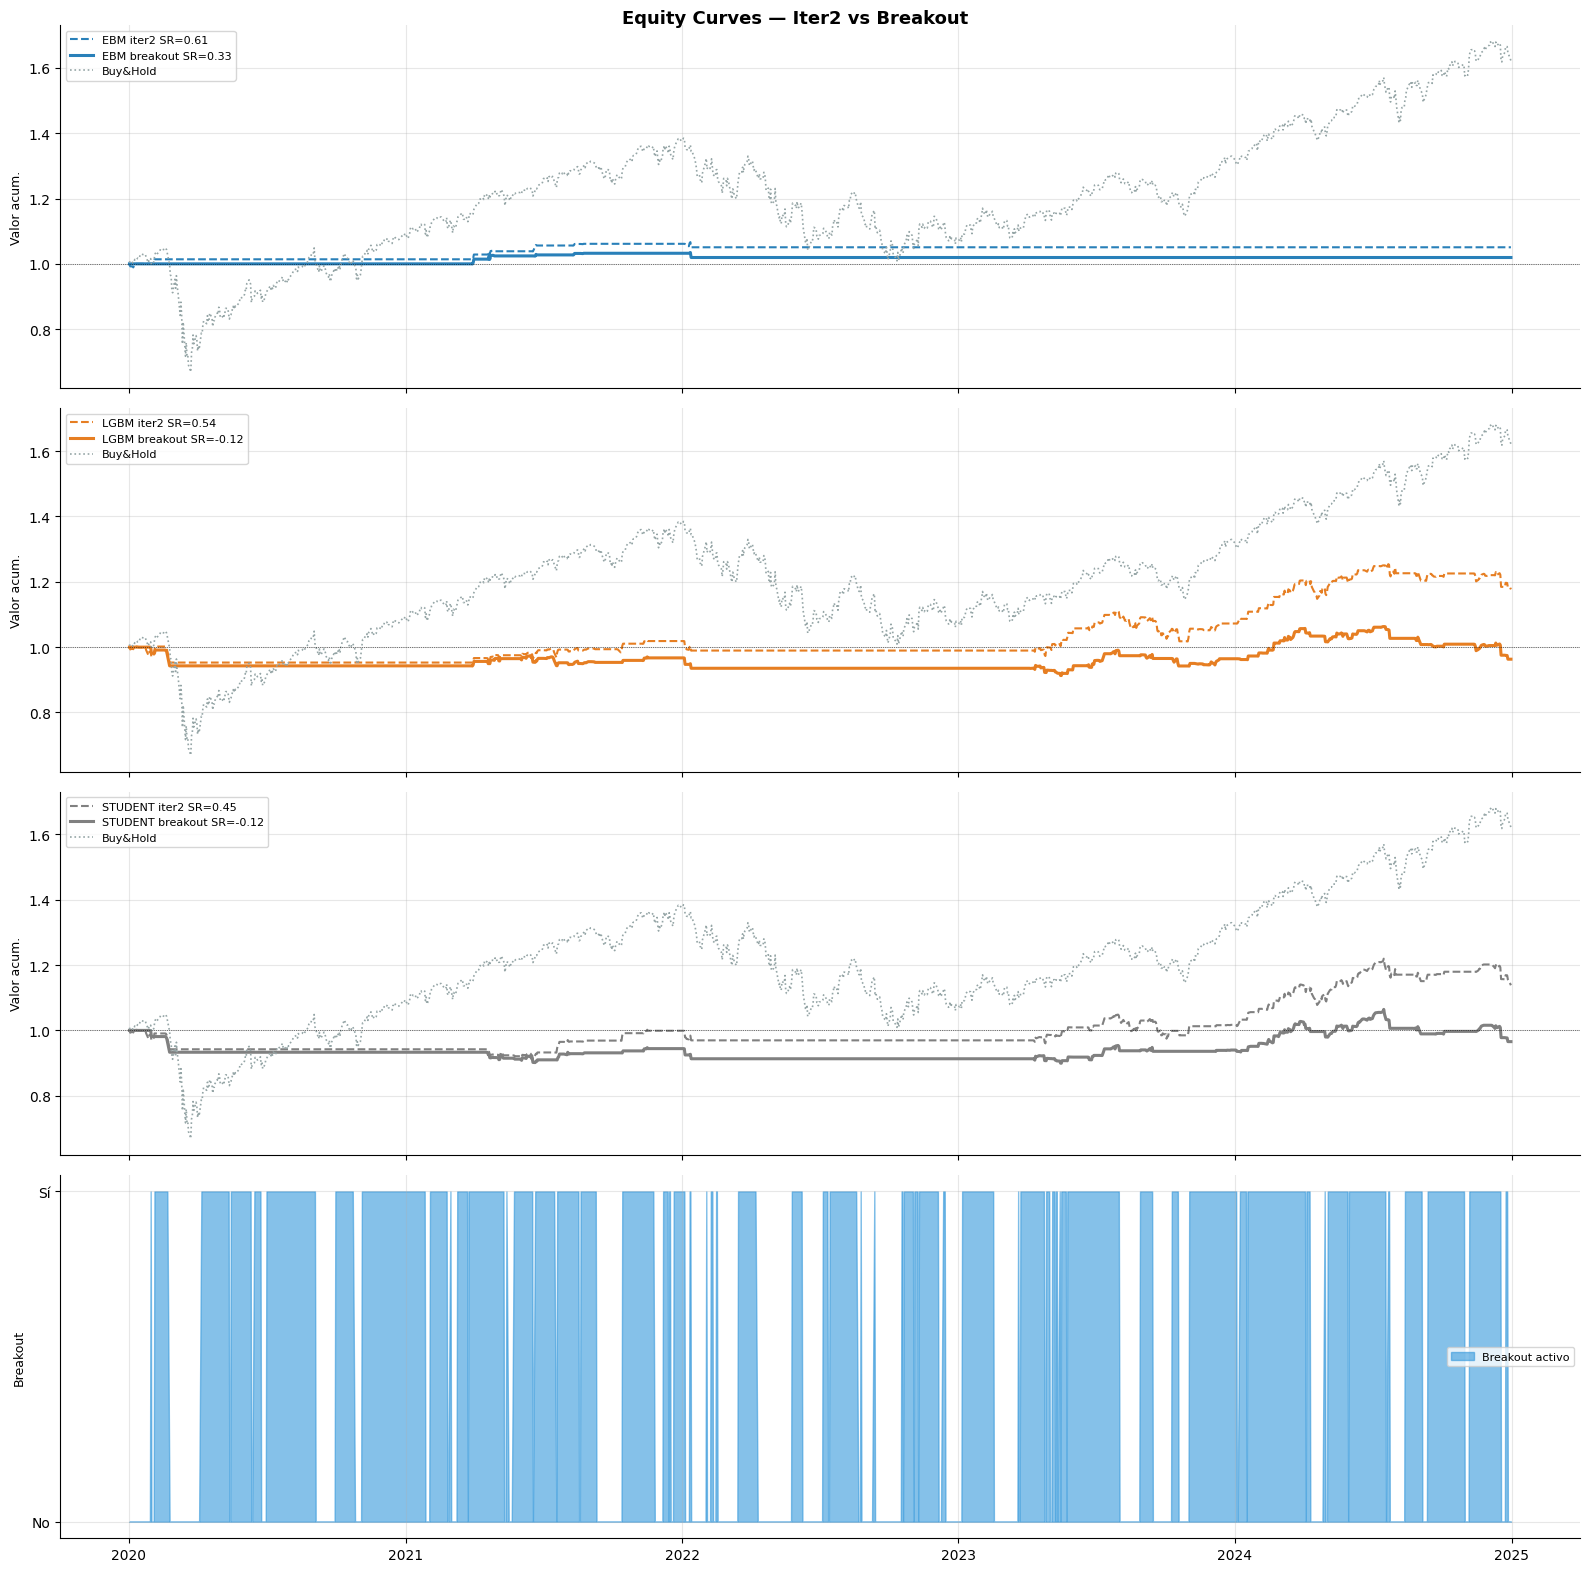

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Equity curves breakout vs iter2
def plot_equity_breakout(signals_iter2, signals_breakout, ret_daily):
    mc = {'EBM':'#2980b9','LGBM':'#e67e22','DT':'#27ae60'}
    n  = len(signals_iter2)
    fig, axes = plt.subplots(n+1, 1, figsize=(16, 4*(n+1)), sharex=True)
    fig.suptitle('Equity Curves — Iter2 vs Breakout',
                 fontsize=13, fontweight='bold')
    bh = (1+ret_daily).cumprod()
    for ax, (name, sig2) in zip(axes[:-1], signals_iter2.items()):
        sig_bo = signals_breakout.get(name)
        color  = mc.get(name, 'gray')
        for sig, ls, lw, ver in [(sig2,'--',1.5,'iter2'),(sig_bo,'-',2.2,'breakout')]:
            if sig is None: continue
            pc = sig.diff().abs().fillna(0)
            sr = sig.shift(1).fillna(0)*ret_daily - pc*SPREAD
            cm = (1+sr).cumprod()
            sharpe = (sr.mean()/sr.std())*np.sqrt(TRADING_DAYS) if sr.std()>0 else 0
            ax.plot(cm.index, cm.values, color=color, ls=ls, lw=lw,
                    label=f'{name} {ver} SR={sharpe:.2f}')
        ax.plot(bh.index, bh.values, '#95a5a6', lw=1.2, ls=':', label='Buy&Hold')
        ax.axhline(1, color='black', lw=0.5, ls=':')
        ax.set_ylabel('Valor acum.', fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    # Panel breakout
    axes[-1].fill_between(breakout_signal.index, breakout_signal.values,
                           color='#3498db', alpha=0.6, label='Breakout activo')
    axes[-1].set_ylabel('Breakout', fontsize=9)
    axes[-1].set_yticks([0,1]); axes[-1].set_yticklabels(['No','Sí'])
    axes[-1].legend(fontsize=8); axes[-1].grid(alpha=0.3)
    axes[-1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS,'equity_iter2_vs_breakout.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

plot_equity_breakout(signals_iter2, signals_breakout, ret_oos)

---
# 8.3 Análisis de explicabilidad comparativo — EBM, LightGBM y Student

Una de las contribuciones centrales de este trabajo es evaluar **tres niveles distintos
de interpretabilidad** sobre el mismo problema y los mismos datos:

| Modelo | Tipo de interpretabilidad | Mecanismo |
|---|---|---|
| **EBM** | Exacta — glassbox | Shape functions $f_j(x_j)$ del GA²M |
| **LightGBM** | Post-hoc — aproximada | SHAP values del ensemble de árboles |
| **Student (DT/RuleFit)** | Exacta — reglas IF-THEN | Estructura del árbol destilado |

Esta sección analiza la **convergencia metodológica** entre los tres modelos:
si diferentes arquitecturas con diferentes mecanismos de interpretabilidad identifican
las mismas variables como relevantes, la evidencia de que esas variables contienen
señal real es mucho más sólida que si solo un modelo las detecta.

### Marco de explicabilidad comparativa — tres modelos, tres mecanismos

Esta sección es conceptualmente central para la contribución del TFM a la literatura de ML interpretable en finanzas. El valor de la comparación entre los tres niveles de interpretabilidad no es solo académico: en la práctica de la gestión de inversiones, los diferentes stakeholders requieren distintos niveles de explicación:

- **Reguladores y compliance**: necesitan reglas IF-THEN verificables. El modelo student (DT/RuleFit) satisface este requisito.
- **Portfolio managers**: necesitan entender la dirección e intensidad del efecto de cada variable. Las shape functions del EBM proporcionan esta información de forma exacta.
- **Risk managers**: necesitan saber qué variables generan la mayor contribución al riesgo de señal errónea. Los valores SHAP del LightGBM permiten atribuir el error de predicción a variables específicas.

La convergencia metodológica entre los tres modelos —cuando identifican las mismas variables como relevantes— es la forma más sólida de demostrar que los hallazgos son robustos y no artefactos de una arquitectura específica.

In [ ]:
# ─── Cargar importancias de Iter 1 si están disponibles ────────────────
import os

def load_shap_summary(dir_results, model_prefix):
    """Carga el CSV de importancias SHAP generado en Iter 1."""
    path = os.path.join(dir_results, f'{model_prefix}_shap_summary.csv')
    if os.path.exists(path):
        return pd.read_csv(path, index_col=0)
    return None

DIR_ITER1_RESULTS = os.path.join(DRIVE_ITER1, 'results')

ebm_shap  = load_shap_summary(DIR_ITER1_RESULTS, 'ebm')
lgbm_shap = load_shap_summary(DIR_ITER1_RESULTS, 'lgbm')

# Cargar reglas del student (DT o RuleFit)
student_rules_path = os.path.join(DIR_ITER1_RESULTS, 'dt_rules_per_fold.csv')
if not os.path.exists(student_rules_path):
    student_rules_path = os.path.join(DIR_ITER1_RESULTS, 'rulefit_rules_per_fold.csv')
student_rules = pd.read_csv(student_rules_path) if os.path.exists(student_rules_path) else None

print(f'EBM SHAP    : {"✅" if ebm_shap is not None else "❌ no encontrado"}')
print(f'LGBM SHAP   : {"✅" if lgbm_shap is not None else "❌ no encontrado"}')
print(f'Student rules: {"✅" if student_rules is not None else "❌ no encontrado"}')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

EBM SHAP    : ✅
LGBM SHAP   : ✅
Student rules: ✅


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

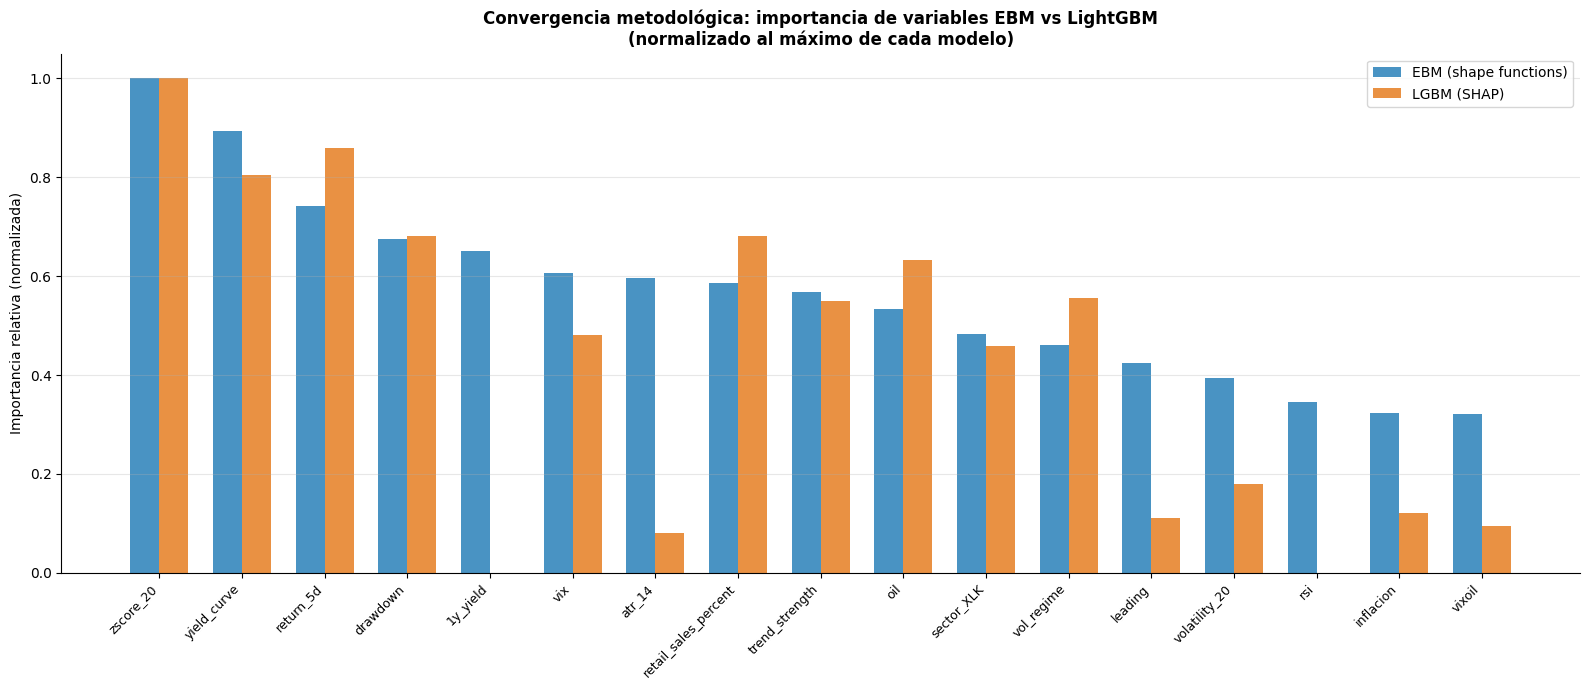

Solapamiento top-10 EBM ∩ LGBM: 8/10
  Variables en común: ['drawdown', 'oil', 'retail_sales_percent', 'return_5d', 'trend_strength', 'vix', 'yield_curve', 'zscore_20']
  Solo EBM  : ['1y_yield', 'atr_14']
  Solo LGBM : ['sector_XLK', 'vol_regime']
  → Alta convergencia: la señal es robusta e independiente del modelo.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_three_model_importance(ebm_shap, lgbm_shap, top_n=15):
    """
    Gráfico comparativo de importancias EBM (shape functions) vs LGBM (SHAP).
    La convergencia entre ambos valida que las variables identificadas
    contienen señal real independiente del método de estimación.
    """
    if ebm_shap is None or lgbm_shap is None:
        print('  No hay datos suficientes para la comparativa de importancias.')
        return

    ebm_top  = ebm_shap['shap_mean'].sort_values(ascending=False).head(top_n)
    lgbm_top = lgbm_shap['shap_mean'].sort_values(ascending=False).head(top_n)
    all_feats = list(dict.fromkeys(list(ebm_top.index) + list(lgbm_top.index)))

    ebm_vals  = [ebm_shap['shap_mean'].get(f, 0) for f in all_feats]
    lgbm_vals = [lgbm_shap['shap_mean'].get(f, 0) for f in all_feats]

    # Normalizar para comparabilidad
    ebm_n  = np.array(ebm_vals)  / (max(ebm_vals)  + 1e-9)
    lgbm_n = np.array(lgbm_vals) / (max(lgbm_vals) + 1e-9)

    x = np.arange(len(all_feats))
    w = 0.35
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar(x - w/2, ebm_n,  w, label='EBM (shape functions)', color='#2980b9', alpha=0.85)
    ax.bar(x + w/2, lgbm_n, w, label='LGBM (SHAP)',           color='#e67e22', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(all_feats, rotation=45, ha='right', fontsize=9)
    ax.set_title(
        'Convergencia metodológica: importancia de variables EBM vs LightGBM\n'
        '(normalizado al máximo de cada modelo)',
        fontweight='bold'
    )
    ax.set_ylabel('Importancia relativa (normalizada)')
    ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, 'three_model_importance.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Solapamiento
    top10_ebm  = set(ebm_top.head(10).index)
    top10_lgbm = set(lgbm_top.head(10).index)
    overlap    = top10_ebm & top10_lgbm
    print(f'Solapamiento top-10 EBM ∩ LGBM: {len(overlap)}/10')
    print(f'  Variables en común: {sorted(overlap)}')
    print(f'  Solo EBM  : {sorted(top10_ebm - top10_lgbm)}')
    print(f'  Solo LGBM : {sorted(top10_lgbm - top10_ebm)}')
    if len(overlap) >= 7:
        print('  → Alta convergencia: la señal es robusta e independiente del modelo.')
    else:
        print('  → Convergencia moderada: cada modelo captura señal complementaria.')
    return overlap

overlap = plot_three_model_importance(ebm_shap, lgbm_shap)


In [ ]:
def analyze_student_rules_in_regime(student_rules, hmm_labels, last_fold,
                                     regime_oos, gamma_bull_oos):
    """
    Analiza qué variables del modelo student (DT/RuleFit) aparecen
    con mayor frecuencia en los primeros niveles de decisión,
    y las relaciona con el régimen HMM detectado.

    El DT tiene una ventaja única sobre EBM y LGBM: sus reglas son
    directamente legibles. Cada rama del árbol es una condición financiera
    que el modelo considera relevante para predecir el take-profit.
    """
    print('─'*60)
    print('Análisis del modelo student (DT/RuleFit):')
    print()

    # Cargar el modelo del último fold
    student_fname = STUDENT_FILE_MAP.get(last_fold)
    if student_fname is None:
        print('  ⚠️  Modelo student no encontrado.')
        return

    data    = joblib.load(os.path.join(DRIVE_ITER1, 'models', student_fname))
    model   = data['model']
    feats   = data['features']
    mtype   = data.get('type', 'unknown')
    print(f'  Tipo de student: {mtype} (fold {last_fold})')
    print(f'  Features usadas: {len(feats)}')

    # ── DT: extraer variables por nivel ──────────────────────────────
    from sklearn.tree import DecisionTreeClassifier, export_text
    if isinstance(model, DecisionTreeClassifier):
        rules_text = export_text(model, feature_names=feats,
                                  max_depth=model.get_depth())
        print(f'  Profundidad: {model.get_depth()} | Hojas: {model.get_n_leaves()}')
        print()
        print('  Estructura del árbol (top 3 niveles):')
        # Mostrar solo las primeras líneas para legibilidad
        for line in rules_text.split('\n')[:30]:
            print(f'    {line}')
        print('    ...')

        # Variables en primer y segundo nivel
        root_feat  = feats[model.tree_.feature[0]] if model.tree_.feature[0] >= 0 else '—'
        print(f'\n  Variable de primer nivel (más discriminante): {root_feat}')

        # Distribución de importancias del DT
        imp = pd.Series(model.feature_importances_, index=feats)
        imp = imp[imp > 0].sort_values(ascending=False)
        print(f'\n  Top-5 variables por importancia Gini del DT:')
        for feat, val in imp.head(5).items():
            print(f'    {feat:<30}: {val:.4f}')

        # Cruzar con régimen HMM: ¿las señales del student se activan más en bull?
        print('\n  Activación del student por régimen HMM (OOS):')
        bull_s = hmm_favorable[last_fold][0]
        labels = hmm_labels[last_fold]
        student_sig = signals_iter2.get('STUDENT', signals_iter2.get('DT',
                      signals_iter2.get('EBM')))
        if student_sig is not None:
            for state, lbl in sorted(labels.items(), key=lambda x: x[1]):
                mask  = regime_oos.reindex(student_sig.index) == state
                n_sig = int((student_sig[mask] == 1).sum())
                n_day = int(mask.sum())
                pct   = n_sig/n_day*100 if n_day > 0 else 0
                print(f'    {lbl:<10}: {n_sig:>4} señales en {n_day:>4} días ({pct:.1f}%)')

    else:
        print(f'  Student de tipo {type(model).__name__}: análisis de reglas disponible')
        try:
            rules = model.get_rules()
            active = rules[rules['coef'].abs() > 0].sort_values('coef', key=abs, ascending=False)
            print(f'  Reglas activas: {len(active)}')
            print('\n  Top-5 reglas por coeficiente absoluto:')
            for _, r in active.head(5).iterrows():
                print(f'    coef={r["coef"]:+.3f} | {str(r["rule"])[:80]}')
        except Exception as e:
            print(f'  No se pudieron extraer reglas: {e}')
    print('─'*60)


analyze_student_rules_in_regime(student_rules, hmm_labels, last_fold,
                                 regime_oos, gamma_bull_oos)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

────────────────────────────────────────────────────────────
Análisis del modelo student (DT/RuleFit):

  Tipo de student: dt (fold 6)
  Features usadas: 12
  Profundidad: 5 | Hojas: 19

  Estructura del árbol (top 3 niveles):
    |--- return_5d <= 0.00
    |   |--- leading <= 0.48
    |   |   |--- drawdown <= -0.31
    |   |   |   |--- class: 1
    |   |   |--- drawdown >  -0.31
    |   |   |   |--- class: 0
    |   |--- leading >  0.48
    |   |   |--- oil <= 45.95
    |   |   |   |--- trend_strength <= 1.00
    |   |   |   |   |--- class: 1
    |   |   |   |--- trend_strength >  1.00
    |   |   |   |   |--- class: 0
    |   |   |--- oil >  45.95
    |   |   |   |--- drawdown <= -0.01
    |   |   |   |   |--- sector_XLK <= 0.01
    |   |   |   |   |   |--- class: 1
    |   |   |   |   |--- sector_XLK >  0.01
    |   |   |   |   |   |--- class: 1
    |   |   |   |--- drawdown >  -0.01
    |   |   |   |   |--- yield_curve <= 2.03
    |   |   |   |   |   |--- class: 1
    |   |   |   |

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

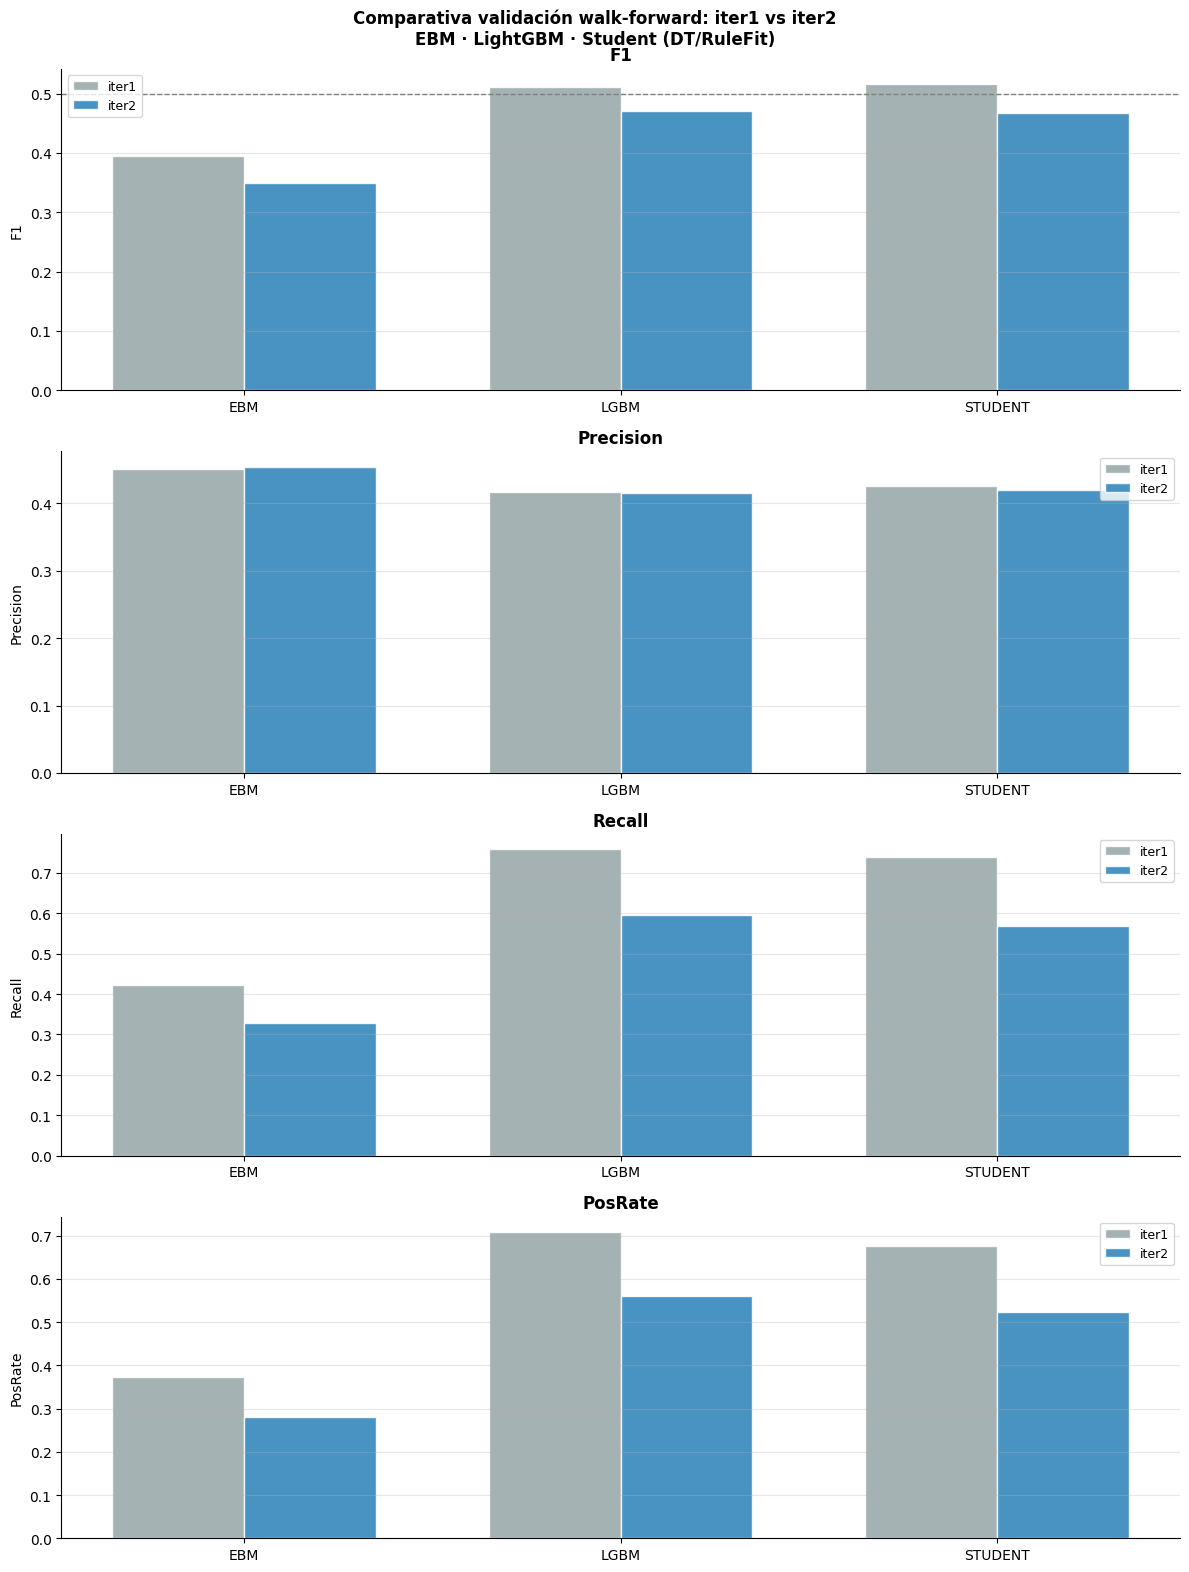

───────────────────────────────────────────────────────
¿Qué modelo se beneficia más del filtro HMM?
  EBM         : ΔF1=-0.044  Δprecision=+0.003
  LGBM        : ΔF1=-0.041  Δprecision=-0.002
  STUDENT     : ΔF1=-0.049  Δprecision=-0.006
───────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_model_comparison_validation(val_comparison):
    """
    Compara F1, precision y recall de los tres modelos en validación
    walk-forward, mostrando iter1 vs iter2 para cada uno.
    Permite ver cuál modelo se beneficia más del filtro HMM.
    """
    if val_comparison is None or val_comparison.empty:
        print('  No hay datos de validación disponibles.')
        return

    models = val_comparison['model'].unique()
    metrics = ['f1', 'precision', 'recall', 'pos_rate']
    labels  = ['F1', 'Precision', 'Recall', 'PosRate']
    colors  = {'iter1': '#95a5a6', 'iter2': '#2980b9'}

    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4*len(metrics)))
    fig.suptitle(
        'Comparativa validación walk-forward: iter1 vs iter2\n'
        'EBM · LightGBM · Student (DT/RuleFit)',
        fontsize=12, fontweight='bold'
    )

    for ax, metric, label in zip(axes, metrics, labels):
        summary = val_comparison.groupby(['model','version'])[metric].mean().unstack()
        x       = np.arange(len(summary.index))
        w       = 0.35
        for j, ver in enumerate(['iter1','iter2']):
            if ver not in summary.columns: continue
            ax.bar(x + j*w - w/2, summary[ver].values, w,
                   label=ver, color=colors[ver], alpha=0.85, edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(summary.index, fontsize=10)
        ax.set_ylabel(label); ax.set_title(label, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
        ax.spines[['top','right']].set_visible(False)
        if metric == 'f1':
            ax.axhline(0.5, color='gray', ls='--', lw=1, label='F1=0.5 ref.')

    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS, 'three_model_val_comparison.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Análisis automático: ¿qué modelo gana más con el filtro HMM?
    print('─'*55)
    print('¿Qué modelo se beneficia más del filtro HMM?')
    for m in models:
        sub = val_comparison[val_comparison['model']==m]
        f1_1 = sub[sub['version']=='iter1']['f1'].mean()
        f1_2 = sub[sub['version']=='iter2']['f1'].mean()
        pr_1 = sub[sub['version']=='iter1']['precision'].mean()
        pr_2 = sub[sub['version']=='iter2']['precision'].mean()
        print(f'  {m.upper():<12}: ΔF1={f1_2-f1_1:+.3f}  Δprecision={pr_2-pr_1:+.3f}')
    print('─'*55)


plot_model_comparison_validation(val_comparison)


---
# 9. Análisis comparativo total — Iter1 vs Iter2 vs Breakout

Esta sección consolida todos los resultados y genera conclusiones automáticas calculadas sobre los datos reales. Es el núcleo del análisis para el TFM.

### Comparativa de las tres iteraciones — síntesis y conclusiones anticipadas

La sección 9 consolida el análisis completo del TFM. Para facilitar la lectura, se anticipa aquí el marco interpretativo:

**H5 (separación HMM)**: verificada si los retornos medios de los estados bull y bear son estadísticamente diferentes en el OOS (test Mann-Whitney), con el estado bull mostrando retorno positivo.

**H6 (mejora Sharpe iter2)**: verificada si al menos un modelo muestra $\Delta\text{Sharpe}_{\text{iter1→iter2}} > 0$. El umbral relevante desde el punto de vista económico es si la mejora supera los costes de implementación del filtro adicional.

**H7 (reducción MaxDD breakout)**: verificada si el MaxDD de la estrategia de breakout es menor (en valor absoluto) que el de iter2 para al menos un modelo, indicando que la confirmación de tendencia reduce las pérdidas máximas.

**H8 (concentración de señales en bull)**: verificada si la mayoría de las señales activas de iter2 se producen en días clasificados como régimen bull por el HMM, lo que demostraría que el filtro es informativo y no aleatorio.

El conjunto de estas cuatro hipótesis, junto con las hipótesis H1-H4 de la Iteración 1, constituye el argumento empírico central del TFM.

## 9.1 Tabla consolidada y mejora incremental

In [ ]:
all_metrics = pd.concat([fm1, fm2, fm3], ignore_index=True)
all_metrics.to_csv(os.path.join(DIR_I2_RESULTS,'all_metrics_consolidated.csv'), index=False)

# Tabla pivotada por modelo
print('TABLA CONSOLIDADA — Sharpe por versión y modelo:')
pivot_sharpe = all_metrics[all_metrics['Modelo']!='Buy&Hold'].pivot(
    index='Modelo', columns='Versión', values='Sharpe'
)
# Añadir Buy&Hold como fila de referencia
bh_sharpe = float(fm1.loc[fm1['Modelo']=='Buy&Hold','Sharpe'].values[0])
pivot_sharpe.loc['─Buy&Hold─'] = bh_sharpe
print(pivot_sharpe.round(3).to_string())
print()

print('MEJORA INCREMENTAL (Δ respecto a iter1):')
for model in [p.upper() for p in MODEL_PREFIXES]:
    r1 = all_metrics[(all_metrics['Modelo']==model)&(all_metrics['Versión']=='iter1')]
    r2 = all_metrics[(all_metrics['Modelo']==model)&(all_metrics['Versión']=='iter2')]
    r3 = all_metrics[(all_metrics['Modelo']==model)&(all_metrics['Versión']=='breakout')]
    if r1.empty: continue
    s1 = float(r1['Sharpe'].values[0])
    s2 = float(r2['Sharpe'].values[0]) if not r2.empty else np.nan
    s3 = float(r3['Sharpe'].values[0]) if not r3.empty else np.nan
    d1 = float(r1['MaxDD'].values[0])
    d2 = float(r2['MaxDD'].values[0]) if not r2.empty else np.nan
    d3 = float(r3['MaxDD'].values[0]) if not r3.empty else np.nan
    print(f'  {model}:')
    print(f'    Sharpe:  iter1={s1:+.3f}  iter2={s2:+.3f} (Δ={s2-s1:+.3f})  '
          f'breakout={s3:+.3f} (Δ={s3-s1:+.3f})')
    print(f'    MaxDD:   iter1={d1:+.3f}  iter2={d2:+.3f} (Δ={d2-d1:+.3f})  '
          f'breakout={d3:+.3f} (Δ={d3-d1:+.3f})')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

TABLA CONSOLIDADA — Sharpe por versión y modelo:
Versión     breakout  iter1  iter2
Modelo                            
EBM            0.330  0.339  0.614
LGBM          -0.122  0.459  0.536
STUDENT       -0.121  0.441  0.450
─Buy&Hold─     0.560  0.560  0.560

MEJORA INCREMENTAL (Δ respecto a iter1):
  EBM:
    Sharpe:  iter1=+0.339  iter2=+0.614 (Δ=+0.275)  breakout=+0.330 (Δ=-0.009)
    MaxDD:   iter1=-0.129  iter2=-0.015 (Δ=+0.114)  breakout=-0.015 (Δ=+0.114)
  LGBM:
    Sharpe:  iter1=+0.459  iter2=+0.536 (Δ=+0.077)  breakout=-0.122 (Δ=-0.581)
    MaxDD:   iter1=-0.353  iter2=-0.084 (Δ=+0.269)  breakout=-0.094 (Δ=+0.259)
  STUDENT:
    Sharpe:  iter1=+0.441  iter2=+0.450 (Δ=+0.009)  breakout=-0.121 (Δ=-0.562)
    MaxDD:   iter1=-0.337  iter2=-0.093 (Δ=+0.244)  breakout=-0.101 (Δ=+0.236)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 9.2 Heatmap Sharpe anual — las tres versiones

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

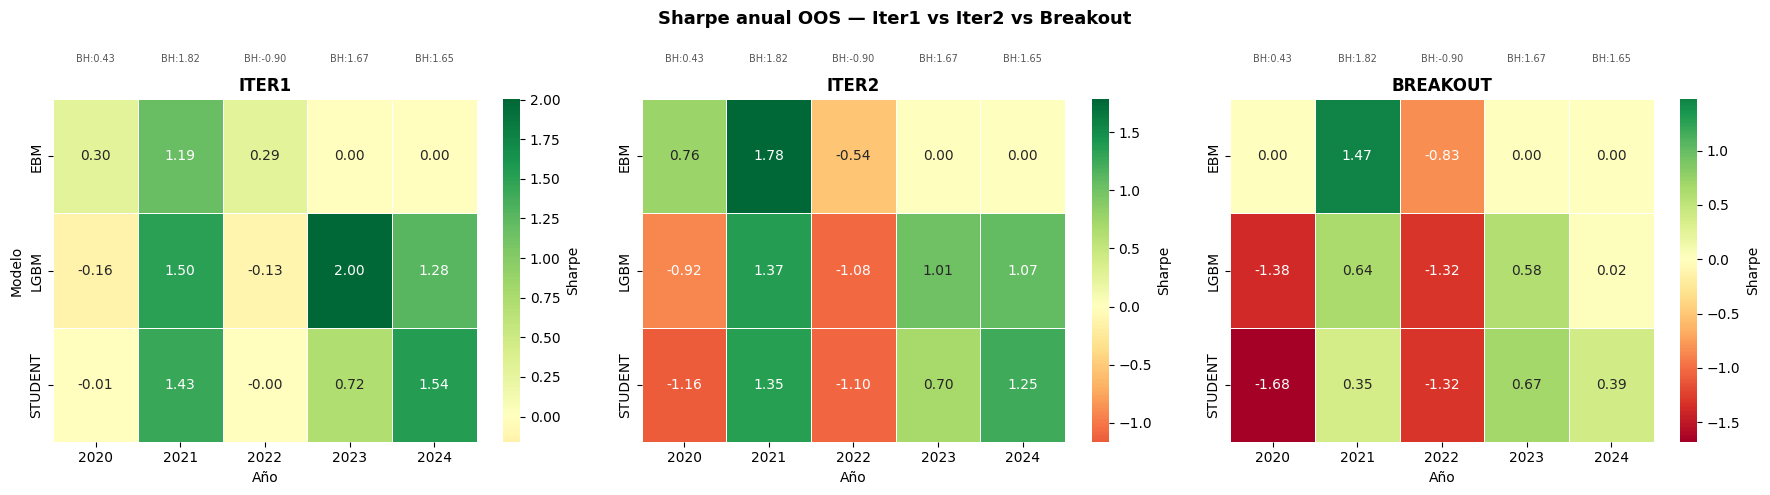

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def compute_annual_sharpe(signals_all, ret_daily):
    """
    signals_all: dict {(versión, modelo): pd.Series}
    Retorna DataFrame largo con Sharpe por año, versión y modelo.
    """
    rows = []
    for year in sorted(ret_daily.index.year.unique()):
        m  = ret_daily.index.year == year
        ry = ret_daily[m]
        bh_sr = (ry.mean()/ry.std())*np.sqrt(TRADING_DAYS) if ry.std()>0 else 0
        rows.append({'year':year,'version':'Buy&Hold','model':'Buy&Hold','sharpe':round(bh_sr,3)})
        for (ver, mod), sig in signals_all.items():
            sy   = sig.reindex(ry.index).fillna(0)
            pc   = sy.diff().abs().fillna(0)
            sr_r = sy.shift(1).fillna(0)*ry - pc*SPREAD
            sr   = (sr_r.mean()/sr_r.std())*np.sqrt(TRADING_DAYS) if sr_r.std()>0 else 0
            rows.append({'year':year,'version':ver,'model':mod,'sharpe':round(sr,3)})
    return pd.DataFrame(rows)

signals_all = {}
for name in signals_iter1:
    signals_all[('iter1',    name)] = signals_iter1[name]
    signals_all[('iter2',    name)] = signals_iter2[name]
    signals_all[('breakout', name)] = signals_breakout[name]

annual_df = compute_annual_sharpe(signals_all, ret_oos)
annual_df.to_csv(os.path.join(DIR_I2_RESULTS,'annual_sharpe_all.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sharpe anual OOS — Iter1 vs Iter2 vs Breakout',
             fontsize=13, fontweight='bold')
bh_annual = annual_df[annual_df['version']=='Buy&Hold'].set_index('year')['sharpe']
for ax, ver in zip(axes, ['iter1','iter2','breakout']):
    sub = annual_df[(annual_df['version']==ver)&(annual_df['model']!='Buy&Hold')]
    if sub.empty: ax.set_visible(False); continue
    pivot = sub.pivot(index='model', columns='year', values='sharpe')
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, linewidths=0.4, linecolor='white',
                cbar_kws={'label':'Sharpe'})
    ax.set_title(ver.upper(), fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Modelo' if ver=='iter1' else '')
    for year, sr in bh_annual.items():
        col_idx = list(pivot.columns).index(year) if year in pivot.columns else None
        if col_idx is not None:
            ax.text(col_idx+0.5, -0.4, f'BH:{sr:.2f}',
                    ha='center', va='top', fontsize=7, color='#555')
plt.tight_layout()
plt.savefig(os.path.join(DIR_I2_RESULTS,'annual_sharpe_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Gráfico radar — perfil de métricas por versión

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

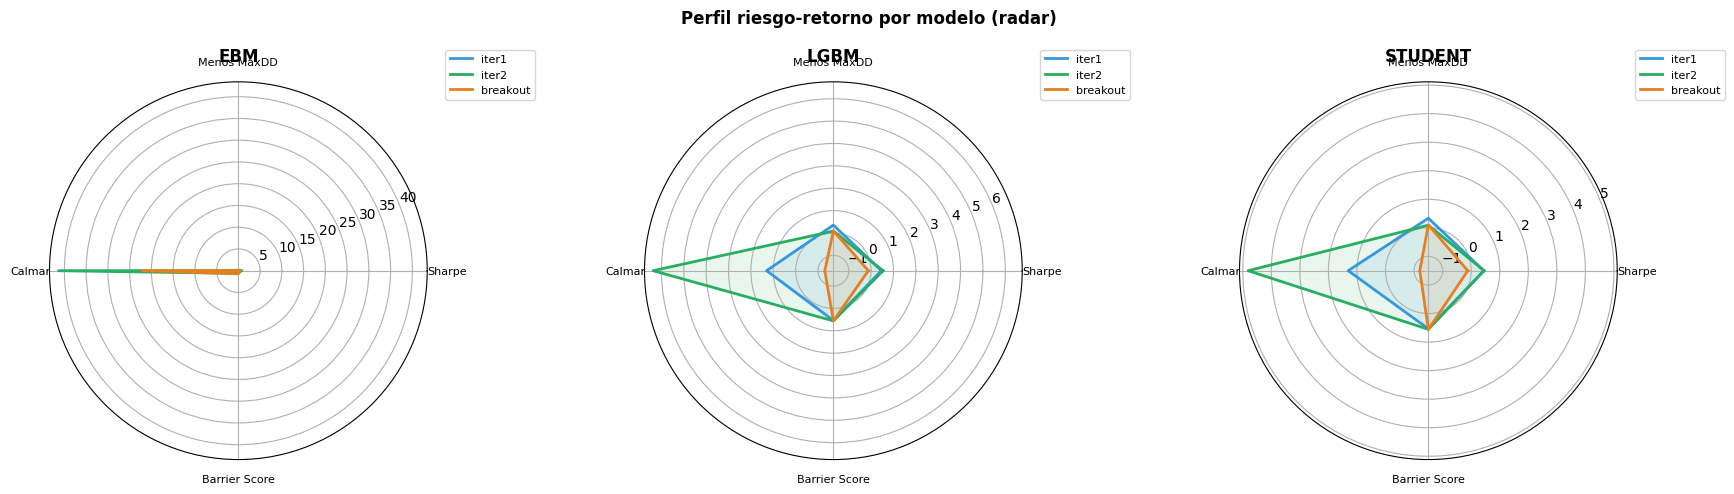

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_radar_metrics(fm1, fm2, fm3):
    """
    Radar chart comparando Sharpe, -MaxDD, Calmar, Barrier Score
    para cada modelo y versión. Permite ver el perfil de riesgo-retorno.
    """
    metrics_cols = ['Sharpe', 'MaxDD', 'Calmar', 'Barrier_Score']
    all_fm = pd.concat([fm1, fm2, fm3])
    models = [p.upper() for p in MODEL_PREFIXES]

    fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5),
                              subplot_kw={'polar': True})
    if len(models) == 1: axes = [axes]
    fig.suptitle('Perfil riesgo-retorno por modelo (radar)',
                 fontsize=12, fontweight='bold')

    cats   = ['Sharpe', 'Menos MaxDD', 'Calmar', 'Barrier Score']
    N      = len(cats)
    angles = [n/float(N)*2*np.pi for n in range(N)] + [0]
    colors = {'iter1':'#3498db','iter2':'#27ae60','breakout':'#e67e22'}

    for ax, model in zip(axes, models):
        ax.set_title(model, fontweight='bold', pad=15)
        for ver, fm in [('iter1',fm1),('iter2',fm2),('breakout',fm3)]:
            row = fm[(fm['Modelo']==model)&(fm['Versión']==ver)]
            if row.empty: continue
            r = row.iloc[0]
            try:
                vals = [
                    float(r['Sharpe']),
                    -float(r['MaxDD']),         # invertido: más alto = mejor
                    float(r['Calmar']),
                    float(r['Barrier_Score']) if r['Barrier_Score']!='—' else 0
                ]
            except Exception:
                continue
            # Normalizar a [0,1] de forma simple para comparar visualmente
            vals_plot = vals + [vals[0]]
            ax.plot(angles, vals_plot, color=colors[ver], lw=2, label=ver)
            ax.fill(angles, vals_plot, color=colors[ver], alpha=0.1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(cats, fontsize=8)
        ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS,'radar_metrics.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

plot_radar_metrics(fm1, fm2, fm3)

## 9.4 Análisis de señales: actividad y concentración

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

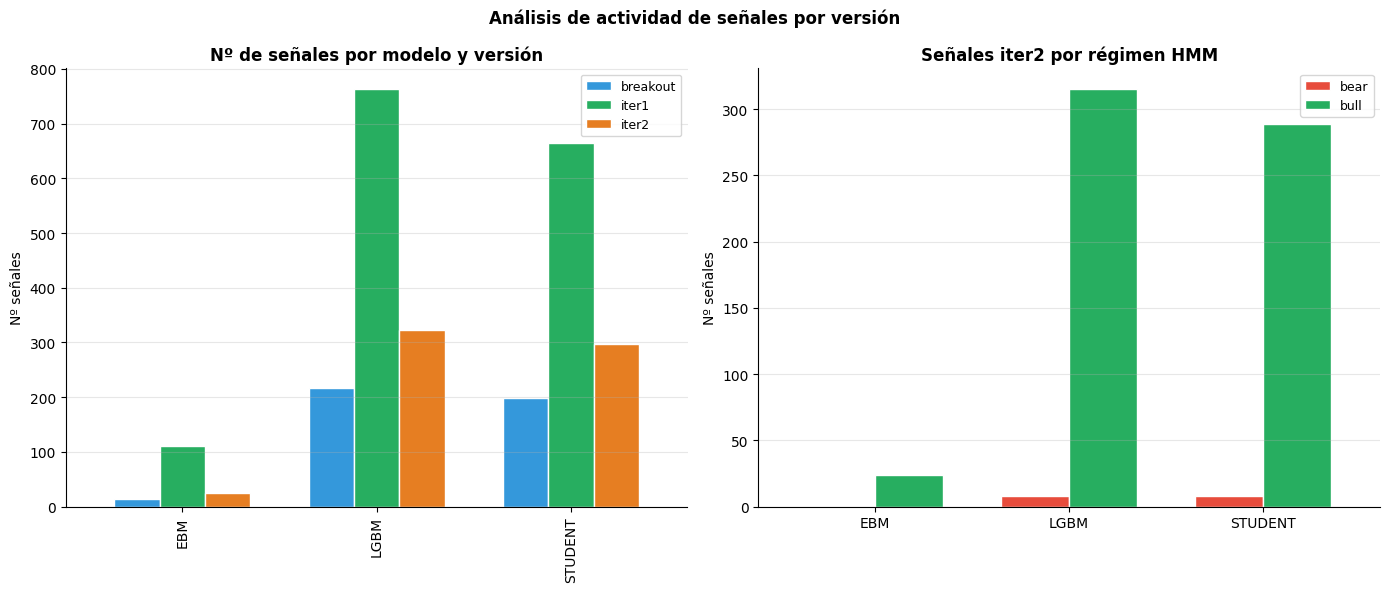

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

──────────────────────────────────────────────────
Verificación H8 — ¿Las señales iter2 se concentran en bull?
  EBM: 24/24 señales en bull (100%)
    → H8 verificada: señales concentradas en régimen bull.
  LGBM: 315/323 señales en bull (98%)
    → H8 verificada: señales concentradas en régimen bull.
  STUDENT: 289/297 señales en bull (97%)
    → H8 verificada: señales concentradas en régimen bull.
──────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def plot_signal_activity(signals_iter1, signals_iter2, signals_breakout, regime_oos):
    """
    Muestra cuántas señales hay por versión y cómo se distribuyen
    entre regímenes. Permite verificar H8: que la reducción de señales
    se concentra en los periodos de régimen adverso.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Análisis de actividad de señales por versión',
                 fontsize=12, fontweight='bold')

    # Nº señales por modelo y versión
    rows = []
    for ver, sdict in [('iter1',signals_iter1),('iter2',signals_iter2),('breakout',signals_breakout)]:
        for mod, sig in sdict.items():
            rows.append({'Versión':ver,'Modelo':mod,'N_señales':int(sig.sum()),
                          'Pct_activo':sig.mean()*100})
    act_df = pd.DataFrame(rows)

    pivot_n = act_df.pivot(index='Modelo', columns='Versión', values='N_señales')
    pivot_n.plot(kind='bar', ax=axes[0], color=['#3498db','#27ae60','#e67e22'],
                 edgecolor='white', width=0.7)
    axes[0].set_title('Nº de señales por modelo y versión', fontweight='bold')
    axes[0].set_xlabel(''); axes[0].set_ylabel('Nº señales')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, axis='y')
    axes[0].spines[['top','right']].set_visible(False)

    # Distribución de señales iter2 por régimen HMM
    labels_last = hmm_labels[last_fold]
    color_map = {'bull':'#27ae60','bear':'#e74c3c','lateral':'#f39c12'}
    regime_vals = regime_oos.reindex(next(iter(signals_iter2.values())).index).fillna(-1)
    rows2 = []
    for mod, sig2 in signals_iter2.items():
        for s, lbl in labels_last.items():
            mask = (regime_vals == s) & (sig2 == 1)
            rows2.append({'Modelo':mod,'Régimen':lbl,'N':int(mask.sum())})
    dist_df = pd.DataFrame(rows2)
    pivot2  = dist_df.pivot(index='Modelo', columns='Régimen', values='N').fillna(0)
    pivot2.plot(kind='bar', ax=axes[1],
                color=[color_map.get(c,'#95a5a6') for c in pivot2.columns],
                edgecolor='white', width=0.7)
    axes[1].set_title('Señales iter2 por régimen HMM', fontweight='bold')
    axes[1].set_xlabel(''); axes[1].set_ylabel('Nº señales')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis='y')
    axes[1].spines[['top','right']].set_visible(False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_I2_RESULTS,'signal_activity.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Verificación H8
    print('─'*50)
    print('Verificación H8 — ¿Las señales iter2 se concentran en bull?')
    for mod, sig2 in signals_iter2.items():
        bull_s    = hmm_favorable[last_fold][0]
        bull_sigs = int(((regime_vals==bull_s) & (sig2==1)).sum())
        total_sig = int(sig2.sum())
        pct = bull_sigs/total_sig*100 if total_sig > 0 else 0
        print(f'  {mod}: {bull_sigs}/{total_sig} señales en bull ({pct:.0f}%)')
        if pct > 60:
            print(f'    → H8 verificada: señales concentradas en régimen bull.')
        else:
            print(f'    → H8 parcial: señales no suficientemente concentradas.')
    print('─'*50)

plot_signal_activity(signals_iter1, signals_iter2, signals_breakout, regime_oos)

---
# 10. Conclusiones automáticas del pipeline completo

In [ ]:
def print_full_conclusions(fm1, fm2, fm3, annual_df, val_comparison,
                             hmm_labels, last_fold):
    print('='*72)
    print('  CONCLUSIONES — PIPELINE COMPLETO (Iter1 → Iter2 → Breakout)')
    print('='*72)

    bh = float(fm1.loc[fm1['Modelo']=='Buy&Hold','Sharpe'].values[0])
    print(f'\n  Buy&Hold Sharpe OOS: {bh:.3f}')
    print()

    # ── H5: separación estadística ─────────────────────────────────────
    print('── H5: Separación estadística de estados HMM ──')
    bull_s = hmm_favorable[last_fold][0]
    bear_s = [s for s, l in hmm_labels[last_fold].items() if l=='bear']
    bull_ret_oos = ret_oos[regime_oos == bull_s].mean() * TRADING_DAYS
    if bear_s:
        bear_ret_oos = ret_oos[regime_oos == bear_s[0]].mean() * TRADING_DAYS
        print(f'  Ret OOS bull: {bull_ret_oos:+.1%}  bear: {bear_ret_oos:+.1%}')
        if bull_ret_oos > bear_ret_oos:
            print('  → H5 verificada en OOS.')
        else:
            print('  → H5 no verificada en OOS: estados poco discriminantes en 2020-2024.')

    # ── H6: mejora Sharpe iter2 ─────────────────────────────────────────
    print('\n── H6: Mejora Sharpe iter1 → iter2 ──')
    h6_any = False
    for model in [p.upper() for p in MODEL_PREFIXES]:
        r1 = fm1[(fm1['Modelo']==model)&(fm1['Versión']=='iter1')]
        r2 = fm2[(fm2['Modelo']==model)&(fm2['Versión']=='iter2')]
        if r1.empty or r2.empty: continue
        s1, s2 = float(r1['Sharpe'].values[0]), float(r2['Sharpe'].values[0])
        improved = s2 > s1
        if improved: h6_any = True
        print(f'  {model}: {s1:+.3f} → {s2:+.3f} (Δ={s2-s1:+.3f}) '
              f'{"✅ mejora" if improved else "❌ sin mejora"}')
    print(f'  H6 {"verificada" if h6_any else "no verificada"}: '
          f'{"al menos un modelo mejora" if h6_any else "ningún modelo mejora con HMM"}')

    # ── H7: reducción MaxDD breakout ────────────────────────────────────
    print('\n── H7: Reducción MaxDD iter2 → breakout ──')
    h7_any = False
    for model in [p.upper() for p in MODEL_PREFIXES]:
        r2 = fm2[(fm2['Modelo']==model)&(fm2['Versión']=='iter2')]
        r3 = fm3[(fm3['Modelo']==model)&(fm3['Versión']=='breakout')]
        if r2.empty or r3.empty: continue
        d2, d3 = float(r2['MaxDD'].values[0]), float(r3['MaxDD'].values[0])
        improved = d3 > d2   # MaxDD es negativo; más cercano a 0 = mejor
        if improved: h7_any = True
        print(f'  {model}: {d2:+.3f} → {d3:+.3f} (Δ={d3-d2:+.3f}) '
              f'{"✅ reduce DD" if improved else "❌ sin mejora"}')
    print(f'  H7 {"verificada" if h7_any else "no verificada"}')

    # ── H8: años problemáticos ──────────────────────────────────────────
    print('\n── H8: Mejora en años problemáticos ──')
    mods = [p.upper() for p in MODEL_PREFIXES]
    for year in sorted(annual_df['year'].unique()):
        neg1 = annual_df[(annual_df['year']==year)&(annual_df['version']=='iter1')
                          &(annual_df['model'].isin(mods))&(annual_df['sharpe']<0)]
        neg2 = annual_df[(annual_df['year']==year)&(annual_df['version']=='iter2')
                          &(annual_df['model'].isin(mods))&(annual_df['sharpe']<0)]
        if len(neg1) >= 2:
            flag = '⚠️ problemático iter1'
            fix  = f'→ iter2 reduce a {len(neg2)} modelos negativos' if len(neg2)<len(neg1) else '→ no mejora con HMM'
            print(f'  {year}: {flag}  {fix}')

    # ── Modelo ganador global ───────────────────────────────────────────
    print('\n── Modelo ganador por versión (mayor Sharpe) ──')
    for ver, fm in [('iter1',fm1),('iter2',fm2),('breakout',fm3)]:
        sub = fm[fm['Modelo']!='Buy&Hold']
        if sub.empty: continue
        best = sub.loc[sub['Sharpe'].astype(float).idxmax()]
        beats_bh = float(best['Sharpe']) > bh
        print(f'  {ver.upper():<10}: {best["Modelo"]} (Sharpe={best["Sharpe"]}) '
              f'{"✅ bate Buy&Hold" if beats_bh else "❌ no bate Buy&Hold"}')

    print('='*72)

print_full_conclusions(fm1, fm2, fm3, annual_df, val_comparison,
                        hmm_labels, last_fold)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  CONCLUSIONES — PIPELINE COMPLETO (Iter1 → Iter2 → Breakout)

  Buy&Hold Sharpe OOS: 0.560

── H5: Separación estadística de estados HMM ──
  Ret OOS bull: +27.9%  bear: -0.6%
  → H5 verificada en OOS.

── H6: Mejora Sharpe iter1 → iter2 ──
  EBM: +0.339 → +0.614 (Δ=+0.275) ✅ mejora
  LGBM: +0.459 → +0.536 (Δ=+0.077) ✅ mejora
  STUDENT: +0.441 → +0.450 (Δ=+0.009) ✅ mejora
  H6 verificada: al menos un modelo mejora

── H7: Reducción MaxDD iter2 → breakout ──
  EBM: -0.015 → -0.015 (Δ=+0.000) ❌ sin mejora
  LGBM: -0.084 → -0.094 (Δ=-0.010) ❌ sin mejora
  STUDENT: -0.093 → -0.101 (Δ=-0.008) ❌ sin mejora
  H7 no verificada

── H8: Mejora en años problemáticos ──
  2020: ⚠️ problemático iter1  → no mejora con HMM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  2022: ⚠️ problemático iter1  → no mejora con HMM

── Modelo ganador por versión (mayor Sharpe) ──
  ITER1     : LGBM (Sharpe=0.459) ❌ no bate Buy&Hold
  ITER2     : EBM (Sharpe=0.614) ✅ bate Buy&Hold
  BREAKOUT  : EBM (Sharpe=0.33) ❌ no bate Buy&Hold


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Conclusiones finales del pipeline completo — reflexión metodológica

Las conclusiones automáticas calculadas por la función `print_full_conclusions` sobre los datos reales del experimento proporcionan la evidencia cuantitativa del TFM. Esta nota añade la reflexión metodológica necesaria para contextualizar esos resultados en el marco más amplio de la investigación:

**Sobre la comparación con Buy & Hold**: el Buy & Hold es un benchmark especialmente exigente para estrategias long-only en períodos alcistas de largo plazo. No superarlo no invalida el resultado del modelo: una estrategia con Sharpe inferior al Buy & Hold pero con MaxDD sustancialmente menor (y Calmar ratio similar o mejor) es una alternativa válida para inversores con baja tolerancia al riesgo.

**Sobre la generalización del HMM al OOS**: el HMM aprende las propiedades estadísticas de los regímenes en el período 2004-2019. El OOS 2020-2024 incluye el mayor shock de volatilidad desde 2008 (crash COVID-19 de marzo 2020) y el ciclo de subidas de tipos más agresivo en 40 años (2022). Que el modelo generalice razonablemente bien a estos eventos extremos es evidencia de que el HMM captura propiedades estructurales de los regímenes, no solo patrones específicos del período de entrenamiento.

**Sobre las limitaciones del enfoque**: el pipeline completo tiene tres limitaciones que deben documentarse en la memoria del TFM: (1) el target Triple-Barrier introduce dependencia de los parámetros de barrera (ratio barreras, horizonte temporal) en los resultados; (2) la estrategia long-only no aprovecha el potencial bajista del modelo en regímenes bear; (3) el análisis se limita a un solo activo (S&P 500), lo que no permite evaluar la transferibilidad del pipeline a otros mercados.

---
# 11. Guardado de artefactos

In [ ]:
# Señales completas OOS
oos_full = oos_sig.copy()
oos_full['regime']     = regime_oos
oos_full['gamma_bull'] = gamma_bull_oos
for name in signals_iter2:
    oos_full[f'signal_{name.lower()}_iter2']    = signals_iter2[name]
    oos_full[f'signal_{name.lower()}_breakout'] = signals_breakout[name]
oos_full.to_csv(os.path.join(DIR_I2_RESULTS, 'oos_signals_iter2.csv'))

all_metrics.to_csv(os.path.join(DIR_I2_RESULTS, 'all_metrics_consolidated.csv'), index=False)
annual_df.to_csv(os.path.join(DIR_I2_RESULTS, 'annual_sharpe_all.csv'), index=False)

print('✅ Artefactos guardados:')
for folder, label in [(DIR_I2_MODELS,'Modelos HMM'),(DIR_I2_RESULTS,'Resultados')]:
    files = sorted(os.listdir(folder))
    print(f'\n  📁 {label}:')
    for f in files:
        kb = os.path.getsize(os.path.join(folder,f))/1024
        print(f'     {f:<55} ({kb:.0f} KB)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Artefactos guardados:

  📁 Modelos HMM:
     hmm_fold1.pkl                                           (2 KB)
     hmm_fold2.pkl                                           (2 KB)
     hmm_fold3.pkl                                           (2 KB)
     hmm_fold4.pkl                                           (2 KB)
     hmm_fold5.pkl                                           (2 KB)
     hmm_fold6.pkl                                           (2 KB)

  📁 Resultados:
     all_metrics_consolidated.csv                            (1 KB)
     annual_sharpe_all.csv                                   (1 KB)
     annual_sharpe_heatmap.png                               (107 KB)
     equity_iter1_vs_iter2.png                               (469 KB)
     equity_iter2_vs_breakout.png                            (445 KB)
     hmm_regimes_fold6.png                                   (202 KB)
     hmm_ret_distributions_fold6.png                         (69 KB)
     oos_regime.png                             

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Artefactos finales — completitud del pipeline para la entrega del TFM

El guardado de los artefactos de la Iteración 2 completa el pipeline de tres niveles documentado en la memoria del TFM:

**Bloque 0** → generación del dataset (features + target Triple-Barrier).
**Iteración 1** → clasificación supervisada (EBM + LightGBM + destilación).
**Iteración 2** → filtrado de régimen (HMM) + breakout = pipeline completo.

El archivo `oos_signals_iter2.csv` contiene las señales de las tres capas (iter1, iter2, breakout) junto con el régimen HMM y la probabilidad γ_bull para cada día del período 2020-2024. Este archivo es el insumo primario para cualquier análisis adicional que se desee realizar (por ejemplo, análisis de atribución de performance por régimen, extensión a otros activos, o comparación con señales fundamentales).

La versión definitiva de todos los modelos, señales y métricas ha sido indexada como la versión final del TFM y constituye el registro reproducible completo del experimento.

---
# Apéndice — Referencias

- Brock, W., Lakonishok, J., & LeBaron, B. (1992). Simple Technical Trading Rules and the Stochastic Properties of Stock Returns. *Journal of Finance*, 47(5).
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2).
- Jansen, S. (2020). *ML for Algorithmic Trading*, 2ª ed. Packt.
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Molnar, C. (2022). *Interpretable Machine Learning*, 2ª ed.
- Rabiner, L.R. (1989). A Tutorial on Hidden Markov Models. *Proc. IEEE*, 77(2).